In [15]:
import pandas as pd
import numpy as np
import json
import yaml
import torch
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML, Image, Markdown
from sklearn.metrics import classification_report, confusion_matrix
import sys

sys.path.append('../')
from src.models.lstm_classifier import LSTMClassifier

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 8)
pd.set_option('display.max_columns', None)

## 1. Selección Automática del Mejor Experimento

In [16]:
EXPERIMENTS_DIR = Path('../experiments')
CLASS_NAMES = ['Normal', 'Robbery']

# Cargar métricas de todos los experimentos
all_metrics = []

for exp_dir in sorted(EXPERIMENTS_DIR.iterdir()):
    if not exp_dir.is_dir():
        continue
    
    exp_name = exp_dir.name
    metrics_path = exp_dir / 'results' / 'tables' / 'lstm_final_metrics.json'
    preds_path = exp_dir / 'results' / 'tables' / 'lstm_test_predictions.json'
    history_path = exp_dir / 'results' / 'tables' / 'lstm_training_history.json'
    
    if metrics_path.exists() and preds_path.exists():
        try:
            with open(metrics_path, 'r') as f:
                final_metrics = json.load(f)
            
            with open(preds_path, 'r') as f:
                test_predictions = json.load(f)
            
            # Calcular overfit / risk_score
            ratio = np.nan
            risk_score = 4
            
            if history_path.exists():
                with open(history_path, 'r') as f:
                    training_history = json.load(f)
                    
                best_epoch = final_metrics.get('best_epoch', None)
                train_losses = training_history.get('train_loss', [])
                val_losses = training_history.get('val_loss', [])
                
                if best_epoch is not None and isinstance(best_epoch, int):
                    train_losses = train_losses[:best_epoch]
                    val_losses = val_losses[:best_epoch]
                    
                if train_losses and val_losses:
                    avg_train_loss = np.mean(train_losses)
                    avg_val_loss = np.mean(val_losses)
                    ratio = avg_val_loss / (avg_train_loss + 1e-6)
                    
                    max_epochs_overfit = [max(0, val - train) for train, val in zip(train_losses, val_losses)]
                    avg_max_overfit = np.mean(max_epochs_overfit) if max_epochs_overfit else 0
                    
                    if ratio > 1.3 or avg_max_overfit > 0.15:
                        risk_score = 3
                    elif ratio > 1.1 or avg_max_overfit > 0.08:
                        risk_score = 2
                    else:
                        risk_score = 1
            
            y_true = test_predictions['labels']
            y_pred = test_predictions['preds']
            
            report_dict = classification_report(y_true, y_pred, target_names=CLASS_NAMES, output_dict=True)
            robbery_metrics = report_dict.get('Robbery', {})
            
            all_metrics.append({
                'experiment': exp_name,
                'f1_robbery': robbery_metrics.get('f1-score', 0.0),
                'recall_robbery': robbery_metrics.get('recall', 0.0),
                'auc': final_metrics.get('test_metrics', {}).get('auc', 0.0),
                'risk_score': risk_score
            })
        except Exception as e:
            print(f"Error cargando {exp_name}: {e}")

# Ordenar por: Menor riesgo de overfitting, luego mayor Recall, F1 y AUC
df_metrics = pd.DataFrame(all_metrics)
if not df_metrics.empty:
    df_metrics = df_metrics.sort_values(
        by=['risk_score', 'recall_robbery', 'f1_robbery', 'auc'],
        ascending=[True, False, False, False]
    )

    # Seleccionar el mejor experimento
    BEST_EXPERIMENT = df_metrics.iloc[0]['experiment']
    BEST_EXP_DIR = EXPERIMENTS_DIR / BEST_EXPERIMENT

    display(Markdown(f"""
### Mejor Experimento Seleccionado: **`{BEST_EXPERIMENT}`**

**Métricas y Criterios:**
- Riesgo de Overfitting (Score): {df_metrics.iloc[0]['risk_score']}
- Recall (Robbery): {df_metrics.iloc[0]['recall_robbery']:.4f}
- F1-Score (Robbery): {df_metrics.iloc[0]['f1_robbery']:.4f}
- AUC (Test): {df_metrics.iloc[0]['auc']:.4f}
"""))

    print(f"\nDirectorio del experimento: {BEST_EXP_DIR.resolve()}")
else:
    print("No se encontraron métricas validas de experimentos.")



### Mejor Experimento Seleccionado: **`exp_69`**

**Métricas y Criterios:**
- Riesgo de Overfitting (Score): 1
- Recall (Robbery): 0.8400
- F1-Score (Robbery): 0.8077
- AUC (Test): 0.8821



Directorio del experimento: D:\Dataset\experiments\exp_69


## 2. Configuración del Experimento

In [17]:
config_path = BEST_EXP_DIR / 'config_run.yml'

if config_path.exists():
    with open(config_path, 'r') as f:
        config = yaml.safe_load(f)
    
    display(Markdown("### Configuración Completa del Experimento"))
    
    # Mostrar configuración organizada
    for section, params in config.items():
        display(Markdown(f"#### {section.upper()}"))
        if isinstance(params, dict):
            df_config = pd.DataFrame(list(params.items()), columns=['Parámetro', 'Valor'])
            display(df_config)
        else:
            print(f"{section}: {params}")
        print()
else:
    print("No se encontró archivo de configuración.")

### Configuración Completa del Experimento

#### RANDOM_SEED

random_seed: 42



#### EXPERIMENT

,Parámetro,Valor
0,name,exp_69
1,base_dir,../experiments


...

,Parámetro,Valor
0,epochs,60
1,patience,10


#### OPTUNA_SEARCH

,Parámetro,Valor
0,n_trials,100
1,results_csv_name,optuna_lstm_trials.csv


#### MODEL_ARTIFACTS

,Parámetro,Valor
0,models_subdir,results/models
1,final_model_name,best_lstm_model.pth
2,final_metrics_name,lstm_final_metrics.json
3,training_history_name,lstm_training_history.json
4,test_predictions_name,lstm_test_predictions.json
5,plots_subdir,results/plots


## 3. Búsqueda de Hiperparámetros con Optuna

### 3.1 Resultados de Optuna

### Resumen de Búsqueda de Hiperparámetros


- **Total de trials:** 100
- **Trials completados:** 90
- **Trials podados:** 10
- **Mejor valor (val_loss):** 0.180787
    

### Top 10 Mejores Trials

,number,value,params_hidden_size,params_num_layers,params_bidirectional,params_dropout_fc,params_lr,params_weight_decay,params_batch_size
7,7,0.180787,192,2,True,0.26,0.000883,0.000324,64
63,63,0.205757,256,1,True,0.35,0.001108,0.000205,64
61,61,0.209447,256,1,True,0.37,0.001076,0.000152,64
75,75,0.216210,256,1,True,0.36,0.001316,0.000137,64
83,83,0.219779,256,1,True,0.41,0.001618,0.000107,64
8,8,0.223443,64,1,True,0.37,0.001531,0.000620,16
68,68,0.223837,256,1,True,0.39,0.001549,0.000307,64
69,69,0.224340,256,1,True,0.38,0.001603,0.000308,64
39,39,0.226395,192,2,False,0.22,0.001953,0.000096,64
37,37,0.226411,192,2,True,0.20,0.001279,0.000129,64


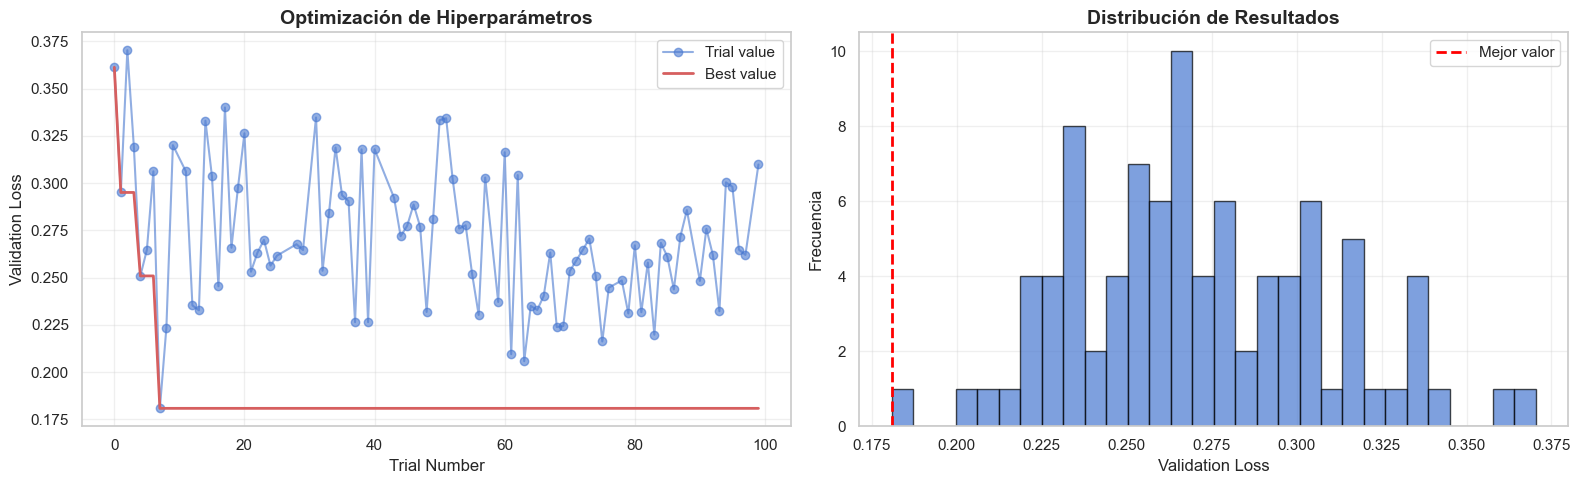

In [18]:
optuna_results_path = BEST_EXP_DIR / 'results' / 'tables' / 'optuna_lstm_trials.csv'

if optuna_results_path.exists():
    df_optuna = pd.read_csv(optuna_results_path)
    
    display(Markdown(f"### Resumen de Búsqueda de Hiperparámetros"))
    display(Markdown(f"""
- **Total de trials:** {len(df_optuna)}
- **Trials completados:** {len(df_optuna[df_optuna['state'] == 'COMPLETE'])}
- **Trials podados:** {len(df_optuna[df_optuna['state'] == 'PRUNED'])}
- **Mejor valor (val_loss):** {df_optuna['value'].min():.6f}
    """))
    
    # Top 10 mejores trials
    display(Markdown("### Top 10 Mejores Trials"))
    top_trials = df_optuna.nsmallest(10, 'value')[[
        'number', 'value', 'params_hidden_size', 'params_num_layers', 
        'params_bidirectional', 'params_dropout_fc', 'params_lr', 
        'params_weight_decay', 'params_batch_size'
    ]]
    display(top_trials.style.format({
        'value': '{:.6f}',
        'params_lr': '{:.6f}',
        'params_weight_decay': '{:.6f}',
        'params_dropout_fc': '{:.2f}'
    }).background_gradient(cmap='Greens_r', subset=['value']))
    
    # Visualización: Evolución del mejor valor
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Gráfico 1: Historial de optimización
    completed_trials = df_optuna[df_optuna['state'] == 'COMPLETE']
    axes[0].plot(completed_trials['number'], completed_trials['value'], 'o-', alpha=0.6, label='Trial value')
    axes[0].plot(completed_trials['number'], completed_trials['value'].cummin(), 'r-', linewidth=2, label='Best value')
    axes[0].set_xlabel('Trial Number', fontsize=12)
    axes[0].set_ylabel('Validation Loss', fontsize=12)
    axes[0].set_title('Optimización de Hiperparámetros', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    #Gráfico 2: Distribución de valores
    axes[1].hist(completed_trials['value'], bins=30, edgecolor='black', alpha=0.7)
    axes[1].axvline(completed_trials['value'].min(), color='red', linestyle='--', linewidth=2, label='Mejor valor')
    axes[1].set_xlabel('Validation Loss', fontsize=12)
    axes[1].set_ylabel('Frecuencia', fontsize=12)
    axes[1].set_title('Distribución de Resultados', fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("No se encontró archivo de resultados de Optuna.")

### 3.1.1 Scatter Plots: Relación Hiperparámetro-Desempeño

Visualización consolidada mostrando la relación entre cada hiperparámetro y el loss de validación para identificar patrones óptimos. Cada gráfico muestra todos los 90 trials completados (puntos claros) y destaca los top-10 mejores trials (puntos coloreados).

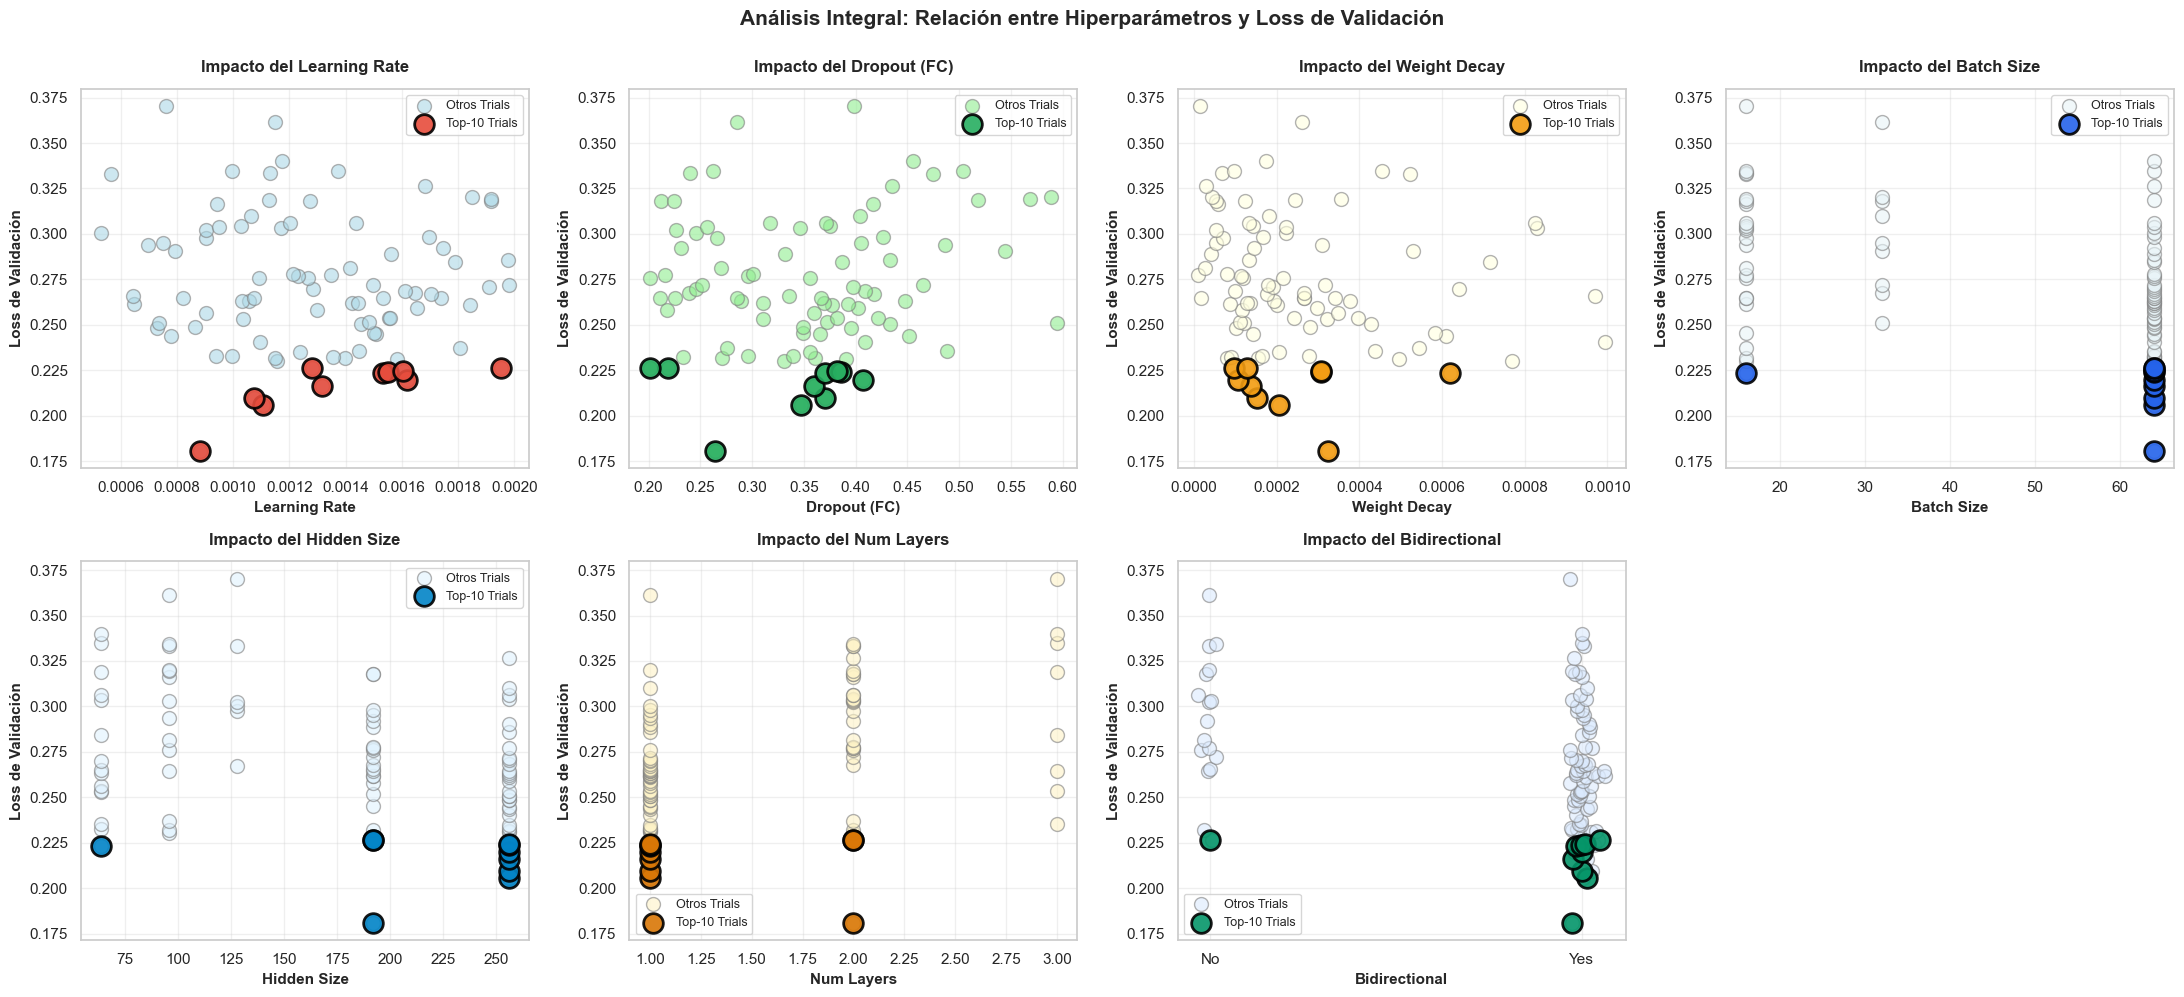

In [19]:
# Cargar datos de Optuna del experimento 69
optuna_file = Path('../experiments/exp_69/results/tables/optuna_lstm_trials.csv')
optuna_df = pd.read_csv(optuna_file)

# Filtrar solo trials completados (no PRUNED)
optuna_df_complete = optuna_df[optuna_df['state'] == 'COMPLETE'].copy()

# Ordenar por loss (value) y obtener top-10
optuna_df_complete = optuna_df_complete.sort_values('value')
top10_trials = optuna_df_complete.head(10).copy()

# Crear columna de ranking
top10_trials['rank'] = range(1, len(top10_trials) + 1)

# Renombrar columnas para mejor legibilidad
param_columns = {
    'params_batch_size': 'Batch Size',
    'params_bidirectional': 'Bidirectional',
    'params_dropout_fc': 'Dropout',
    'params_hidden_size': 'Hidden Size',
    'params_lr': 'Learning Rate',
    'params_num_layers': 'Num Layers',
    'params_weight_decay': 'Weight Decay'
}

top10_trials = top10_trials.rename(columns=param_columns)

# Scatter plots de TODOS los hiperparámetros vs Loss de Validación
# Reutilizando los datos ya cargados: optuna_df_complete y top10_trials
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

# Configuración de cada subplot: (índice, parámetro, label, color_light, color_top)
plot_configs = [
    (0, 'params_lr', 'Learning Rate', 'lightblue', '#e74c3c', 'Learning Rate'),
    (1, 'params_dropout_fc', 'Dropout', 'lightgreen', '#27ae60', 'Dropout (FC)'),
    (2, 'params_weight_decay', 'Weight Decay', 'lightyellow', '#f39c12', 'Weight Decay'),
    (3, 'params_batch_size', 'Batch Size', '#e8f4f8', '#2563eb', 'Batch Size'),
    (4, 'params_hidden_size', 'Hidden Size', '#e0f2fe', '#0284c7', 'Hidden Size'),
    (5, 'params_num_layers', 'Num Layers', '#fef3c7', '#d97706', 'Num Layers'),
    (6, 'params_bidirectional', 'Bidirectional', '#dbeafe', '#059669', 'Bidirectional'),
]

# Graficar cada hiperparámetro
for idx, param, label, color_light, color_top, title in plot_configs:
    ax = axes[idx]
    
    if label == 'Bidirectional':
        # Para Bidirectional, convertir boolean a numérico con jitter
        all_param_numeric = optuna_df_complete[param].astype(int)
        top10_param_numeric = top10_trials[label].map({'Yes': 1, 'No': 0, True: 1, False: 0}).astype(int)
        
        scatter = ax.scatter(all_param_numeric + np.random.normal(0, 0.02, len(all_param_numeric)), 
                           optuna_df_complete['value'], 
                           alpha=0.6, s=100, c=color_light, edgecolors='gray', linewidth=1, label='Otros Trials')
        scatter_top = ax.scatter(top10_param_numeric + np.random.normal(0, 0.02, len(top10_param_numeric)), 
                               top10_trials['value'], 
                               alpha=0.9, s=200, c=color_top, edgecolors='black', linewidth=2, label='Top-10 Trials', zorder=5)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['No', 'Yes'])
    else:
        # Para parámetros continuos o discretos normales
        scatter = ax.scatter(optuna_df_complete[param], optuna_df_complete['value'], 
                           alpha=0.6, s=100, c=color_light, edgecolors='gray', linewidth=1, label='Otros Trials')
        scatter_top = ax.scatter(top10_trials[label], top10_trials['value'], 
                               alpha=0.9, s=200, c=color_top, edgecolors='black', linewidth=2, label='Top-10 Trials', zorder=5)
    
    ax.set_xlabel(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Loss de Validación', fontsize=11, fontweight='bold')
    ax.set_title(f'Impacto del {title}', fontsize=12, fontweight='bold', pad=12)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, loc='best')

# Eliminar el último subplot vacío (índice 7)
fig.delaxes(axes[7])

plt.suptitle('Análisis Integral: Relación entre Hiperparámetros y Loss de Validación', 
             fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

### 3.1.2 Gráfico de Coordenadas Paralelas

Visualización que muestra cómo se combinan los hiperparámetros en los 10 mejores trials, permitiendo ver patrones de asociación entre variables

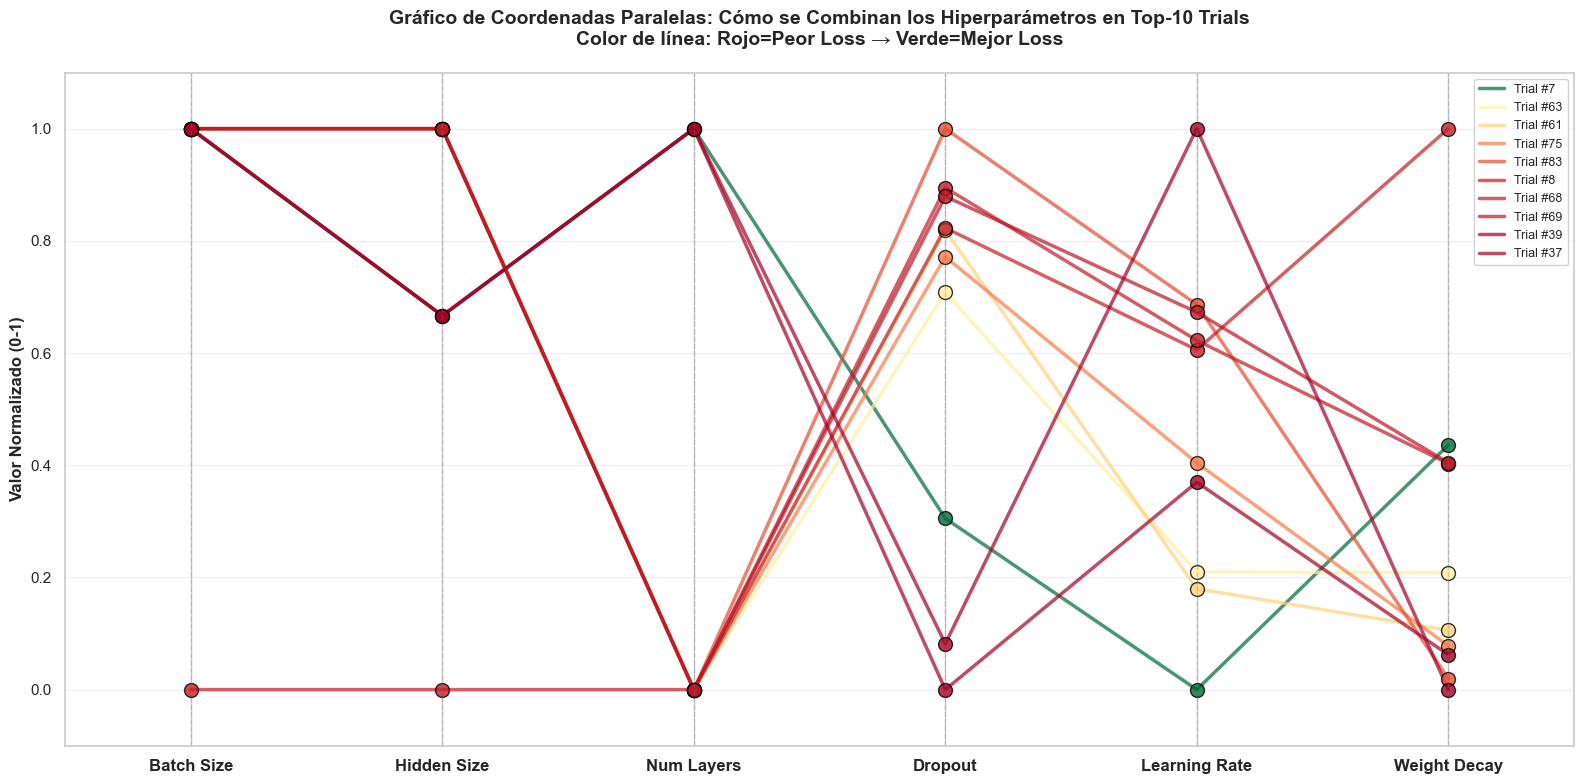


Interpretación:
- Las líneas muestran cómo se combinan los hiperparámetros para cada trial
- Color verde: Trials con mejor (menor) loss de validación
- Color rojo: Trials con peor (mayor) loss de validación
- Las líneas que convergen indican correlaciones entre hiperparámetros


In [20]:
# Parallel Coordinates Plot - Mostrar cómo se combinan los hiperparámetros
fig, ax = plt.subplots(figsize=(16, 8))

# Normalizar parámetros para el gráfico (escalar a rango 0-1 para mejor visualización)
top10_normalized = top10_trials.copy()

# Parámetros a incluir en el Parallel Coordinates Plot
params_to_include = ['Batch Size', 'Hidden Size', 'Num Layers', 'Dropout', 'Learning Rate', 'Weight Decay']

# Normalizar cada parámetro
normalized_data = {}
for param in params_to_include:
    values = top10_trials[param].values
    min_val = values.min()
    max_val = values.max()
    
    if max_val > min_val:
        normalized_data[param] = (values - min_val) / (max_val - min_val)
    else:
        normalized_data[param] = np.ones_like(values) * 0.5

# Crear el gráfico de coordenadas paralelas manualmente
num_params = len(params_to_include)
num_trials = len(top10_trials)

# Definir colores basados en loss
loss_values = top10_trials['value'].values
loss_normalized = (loss_values - loss_values.min()) / (loss_values.max() - loss_values.min())
colors = plt.cm.RdYlGn_r(loss_normalized)

# Graficar líneas para cada trial
for trial_idx in range(num_trials):
    y_values = [normalized_data[param][trial_idx] for param in params_to_include]
    ax.plot(range(num_params), y_values, color=colors[trial_idx], alpha=0.7, linewidth=2.5, 
            label=f"Trial #{int(top10_trials.iloc[trial_idx]['number'])}", zorder=1)
    
    # Agregar puntos en cada eje
    ax.scatter(range(num_params), y_values, color=colors[trial_idx], s=100, 
              edgecolors='black', linewidth=1, zorder=2, alpha=0.8)

# Configurar ejes
ax.set_xticks(range(num_params))
ax.set_xticklabels(params_to_include, fontsize=12, fontweight='bold')
ax.set_ylabel('Valor Normalizado (0-1)', fontsize=12, fontweight='bold')
ax.set_ylim([-0.1, 1.1])
ax.set_xlim([-0.5, num_params - 0.5])

# Agregar líneas verticales para separar parámetros
for x in range(num_params):
    ax.axvline(x=x, color='gray', linestyle='--', alpha=0.3, linewidth=1)

# Título descriptivo y claro
ax.set_title('Gráfico de Coordenadas Paralelas: Cómo se Combinan los Hiperparámetros en Top-10 Trials\n' + 
             'Color de línea: Rojo=Peor Loss → Verde=Mejor Loss', 
             fontsize=14, fontweight='bold', pad=20)

ax.grid(axis='y', alpha=0.3)
ax.legend(loc='upper right', fontsize=9, ncol=1, framealpha=0.9)
plt.tight_layout()
plt.show()

print("\nInterpretación:")
print("- Las líneas muestran cómo se combinan los hiperparámetros para cada trial")
print("- Color verde: Trials con mejor (menor) loss de validación")
print("- Color rojo: Trials con peor (mayor) loss de validación")
print("- Las líneas que convergen indican correlaciones entre hiperparámetros")

### 3.2 Mejores Hiperparámetros Encontrados

In [21]:
metrics_path = BEST_EXP_DIR / 'results' / 'tables' / 'lstm_final_metrics.json'

if metrics_path.exists():
    with open(metrics_path, 'r') as f:
        final_metrics = json.load(f)
    
    best_hyperparams = final_metrics.get('best_hyperparameters', {})
    
    display(Markdown("### Mejor Combinación de Hiperparámetros (Optuna)"))
    df_best_params = pd.DataFrame(list(best_hyperparams.items()), columns=['Hiperparámetro', 'Valor'])
    display(df_best_params.style.set_properties(**{'font-weight': 'bold'}))
    
    display(Markdown(f"""
**Métricas del mejor trial:**
- Validation Loss: {final_metrics.get('best_validation_loss', 'N/A'):.6f}
- Validation AUC: {final_metrics.get('best_validation_auc', 'N/A'):.4f}
- Mejor Epoch: {final_metrics.get('best_epoch', 'N/A')}
    """))
else:
    print("No se encontró archivo de métricas finales.")

### Mejor Combinación de Hiperparámetros (Optuna)

,Hiperparámetro,Valor
0,hidden_size,192
1,num_layers,2
2,bidirectional,True
3,lr,0.000883
4,weight_decay,0.000324
5,batch_size,64
6,dropout_fc,0.264489



**Métricas del mejor trial:**
- Validation Loss: 0.180787
- Validation AUC: 0.9785
- Mejor Epoch: 7
    

## 4. Entrenamiento del Modelo Final

### 4.1 Historial de Entrenamiento

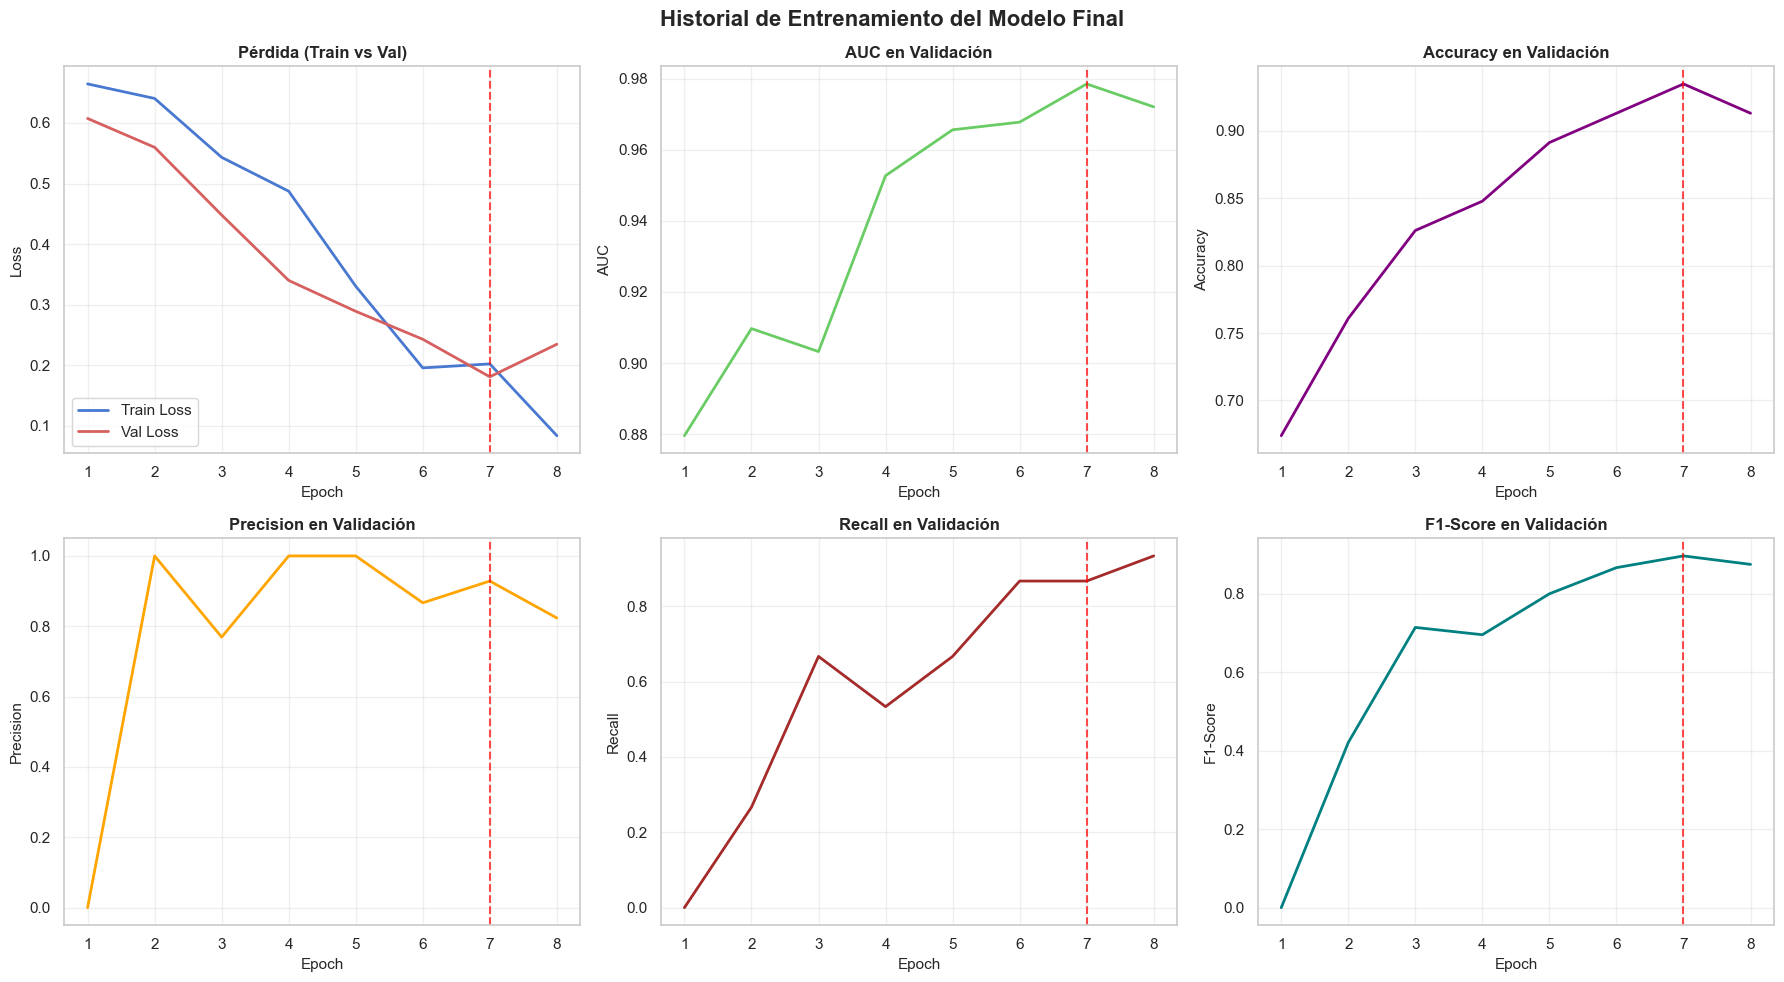


**Resumen del Entrenamiento:**
- Total de epochs ejecutados: 17
- Mejor epoch: 7
- Mejor val_loss: 0.180787
- Mejor val_auc: 0.9785
    

In [22]:
history_path = BEST_EXP_DIR / 'results' / 'tables' / 'lstm_training_history.json'

if history_path.exists():
    with open(history_path, 'r') as f:
        history = json.load(f)
    
    best_ep = final_metrics.get('best_epoch', 1)
    limit = best_ep + 1
    
    max_len = len(history['train_loss'])
    if limit > max_len:
        limit = max_len
        
    epochs = list(range(1, limit + 1))
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Historial de Entrenamiento del Modelo Final', fontsize=16, fontweight='bold')
    
    # Gráfico 1: Pérdida
    axes[0, 0].plot(epochs, history['train_loss'][:limit], 'b-', label='Train Loss', linewidth=2)
    axes[0, 0].plot(epochs, history['val_loss'][:limit], 'r-', label='Val Loss', linewidth=2)
    axes[0, 0].set_xlabel('Epoch', fontsize=11)
    axes[0, 0].set_ylabel('Loss', fontsize=11)
    axes[0, 0].set_title('Pérdida (Train vs Val)', fontsize=12, fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Gráfico 2: AUC
    axes[0, 1].plot(epochs, history['val_auc'][:limit], 'g-', linewidth=2)
    axes[0, 1].set_xlabel('Epoch', fontsize=11)
    axes[0, 1].set_ylabel('AUC', fontsize=11)
    axes[0, 1].set_title('AUC en Validación', fontsize=12, fontweight='bold')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Gráfico 3: Accuracy
    axes[0, 2].plot(epochs, history['val_accuracy'][:limit], 'purple', linewidth=2)
    axes[0, 2].set_xlabel('Epoch', fontsize=11)
    axes[0, 2].set_ylabel('Accuracy', fontsize=11)
    axes[0, 2].set_title('Accuracy en Validación', fontsize=12, fontweight='bold')
    axes[0, 2].grid(True, alpha=0.3)
    
    # Gráfico 4: Precision
    axes[1, 0].plot(epochs, history['val_precision'][:limit], 'orange', linewidth=2)
    axes[1, 0].set_xlabel('Epoch', fontsize=11)
    axes[1, 0].set_ylabel('Precision', fontsize=11)
    axes[1, 0].set_title('Precision en Validación', fontsize=12, fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Gráfico 5: Recall
    axes[1, 1].plot(epochs, history['val_recall'][:limit], 'brown', linewidth=2)
    axes[1, 1].set_xlabel('Epoch', fontsize=11)
    axes[1, 1].set_ylabel('Recall', fontsize=11)
    axes[1, 1].set_title('Recall en Validación', fontsize=12, fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3)
    
    # Gráfico 6: F1-Score
    axes[1, 2].plot(epochs, history['val_f1_score'][:limit], 'teal', linewidth=2)
    axes[1, 2].set_xlabel('Epoch', fontsize=11)
    axes[1, 2].set_ylabel('F1-Score', fontsize=11)
    axes[1, 2].set_title('F1-Score en Validación', fontsize=12, fontweight='bold')
    axes[1, 2].grid(True, alpha=0.3)
    
    # Marcar el mejor epoch
    if 'best_epoch' in final_metrics:
        best_epoch = final_metrics['best_epoch']
        if best_epoch <= limit:
            for ax in axes.flat:
                ax.axvline(x=best_epoch, color='red', linestyle='--', alpha=0.7, linewidth=1.5)
    
    plt.tight_layout()
    plt.show()
    
    display(Markdown(f"""
**Resumen del Entrenamiento:**
- Total de epochs ejecutados: {len(history['train_loss'])}
- Mejor epoch: {final_metrics.get('best_epoch', 'N/A')}
- Mejor val_loss: {min(history['val_loss']):.6f}
- Mejor val_auc: {max(history['val_auc']):.4f}
    """))
else:
    print("No se encontró historial de entrenamiento.")

## 5. Evaluación en Conjunto de Test

### 5.1 Métricas Globales

In [23]:
if metrics_path.exists():
    test_metrics = final_metrics.get('test_metrics', {})
    
    display(Markdown("### Métricas en Test"))
    df_test_metrics = pd.DataFrame(list(test_metrics.items()), columns=['Métrica', 'Valor'])
    display(df_test_metrics.style.format({'Valor': '{:.4f}'}).background_gradient(cmap='Blues', subset=['Valor']))

### Métricas en Test

,Métrica,Valor
0,loss,0.5274
1,accuracy,0.8438
2,precision,0.7778
3,recall,0.8400
4,f1_score,0.8077
5,auc,0.8821


### 5.2 Reporte de Clasificación Detallado

In [24]:
preds_path = BEST_EXP_DIR / 'results' / 'tables' / 'lstm_test_predictions.json'

if preds_path.exists():
    with open(preds_path, 'r') as f:
        predictions = json.load(f)
    
    y_true = predictions['labels']
    y_pred = predictions['preds']
    
    report = classification_report(y_true, y_pred, target_names=CLASS_NAMES)
    
    display(Markdown("### Classification Report"))
    display(HTML(f"<pre>{report}</pre>"))
    
    # Análisis por clase
    report_dict = classification_report(y_true, y_pred, target_names=CLASS_NAMES, output_dict=True)
    
    display(Markdown("### Métricas por Clase"))
    df_class_metrics = pd.DataFrame({
        'Clase': CLASS_NAMES,
        'Precision': [report_dict['Normal']['precision'], report_dict['Robbery']['precision']],
        'Recall': [report_dict['Normal']['recall'], report_dict['Robbery']['recall']],
        'F1-Score': [report_dict['Normal']['f1-score'], report_dict['Robbery']['f1-score']],
        'Support': [report_dict['Normal']['support'], report_dict['Robbery']['support']]
    })
    display(df_class_metrics.style.format({
        'Precision': '{:.4f}',
        'Recall': '{:.4f}',
        'F1-Score': '{:.4f}'
    }).background_gradient(cmap='RdYlGn', subset=['Precision', 'Recall', 'F1-Score']))

### Classification Report

### Métricas por Clase

,Clase,Precision,Recall,F1-Score,Support
0,Normal,0.8919,0.8462,0.8684,39.000000
1,Robbery,0.7778,0.8400,0.8077,25.000000


### 5.3 Visualizaciones de Resultados

### Gráficos de Análisis

#### Historial de Entrenamiento

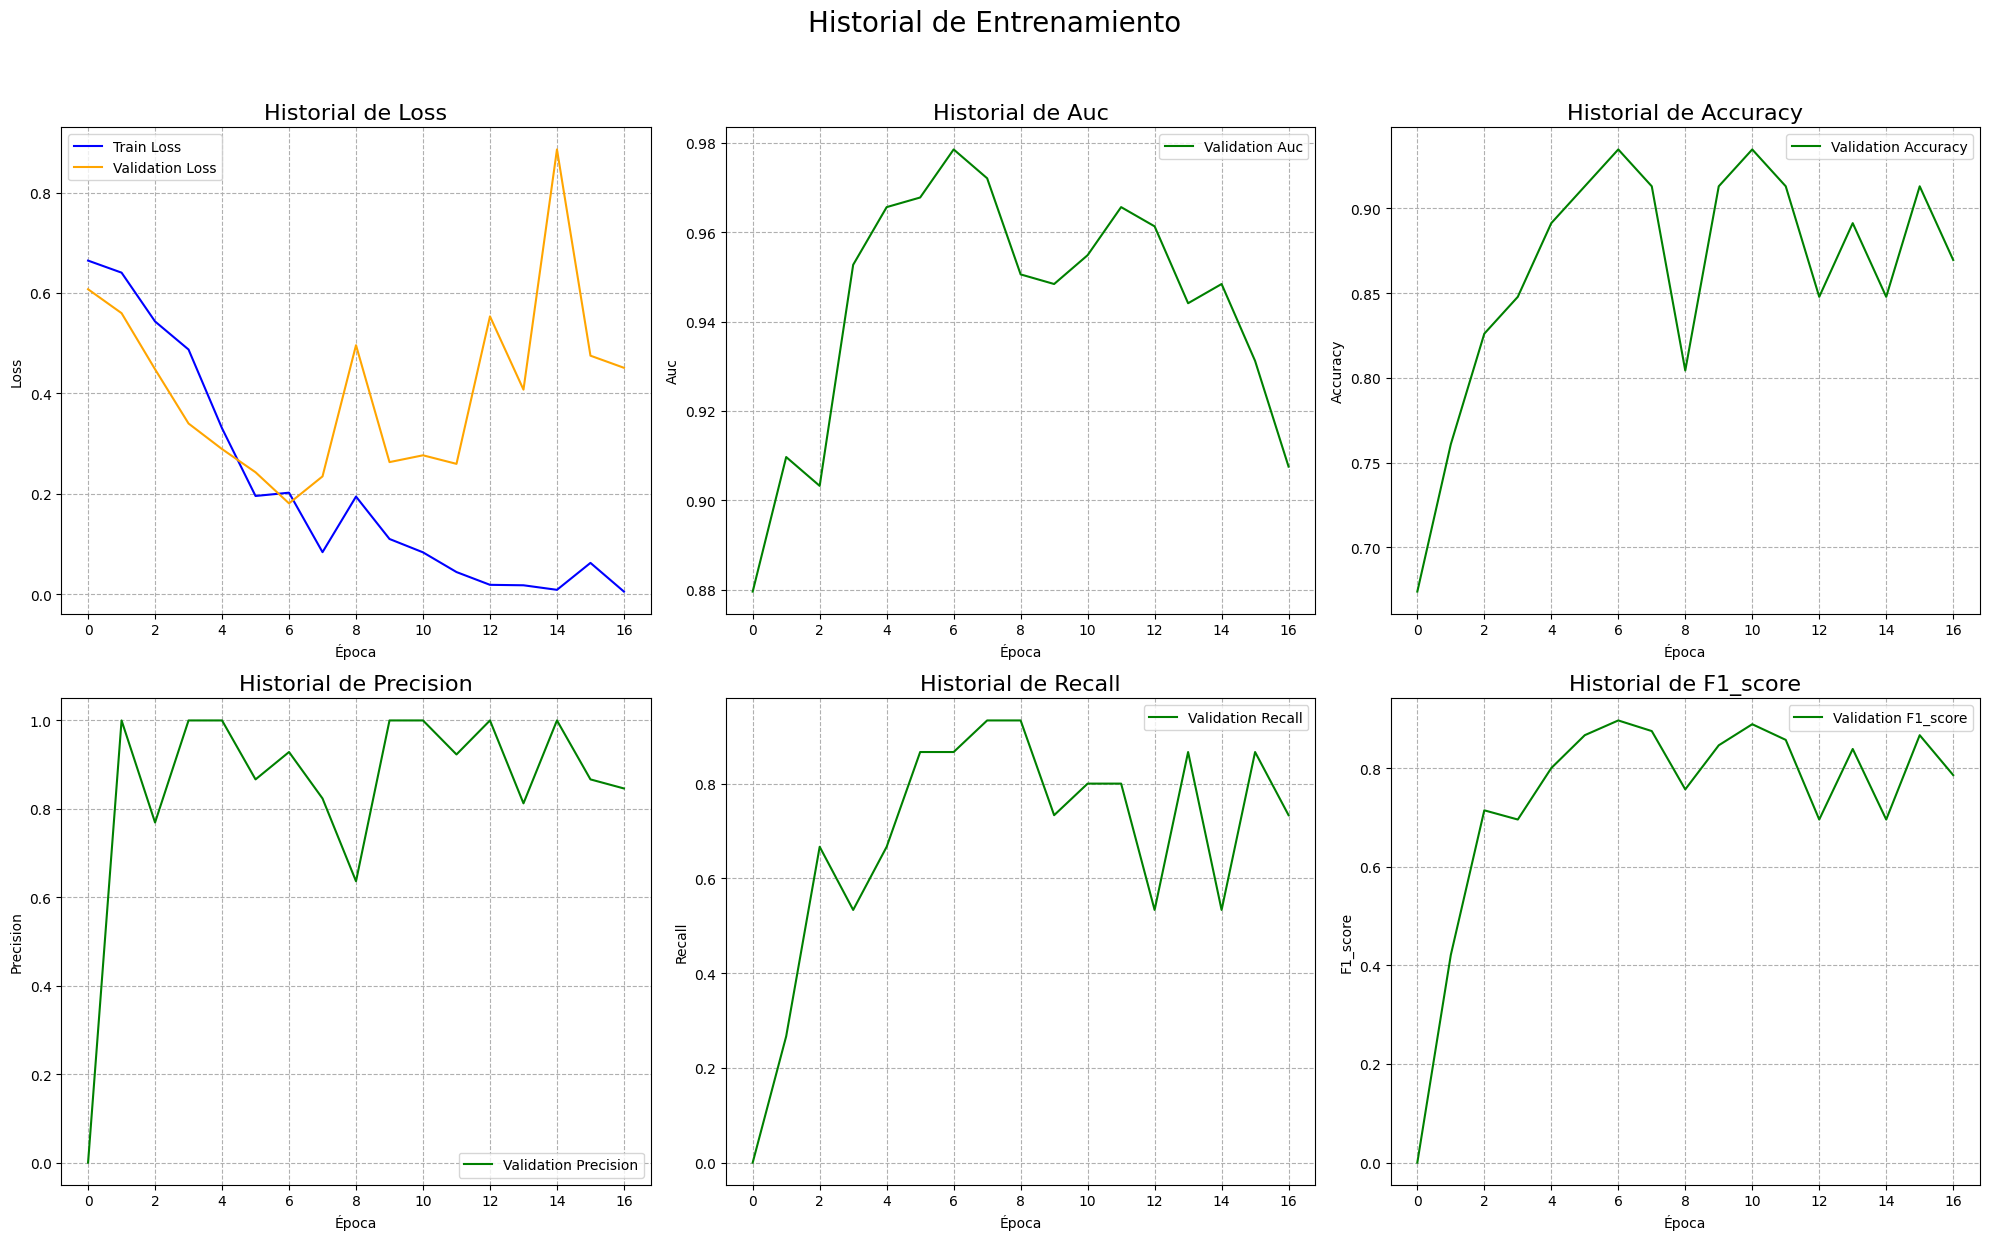

#### Análisis de Clasificación

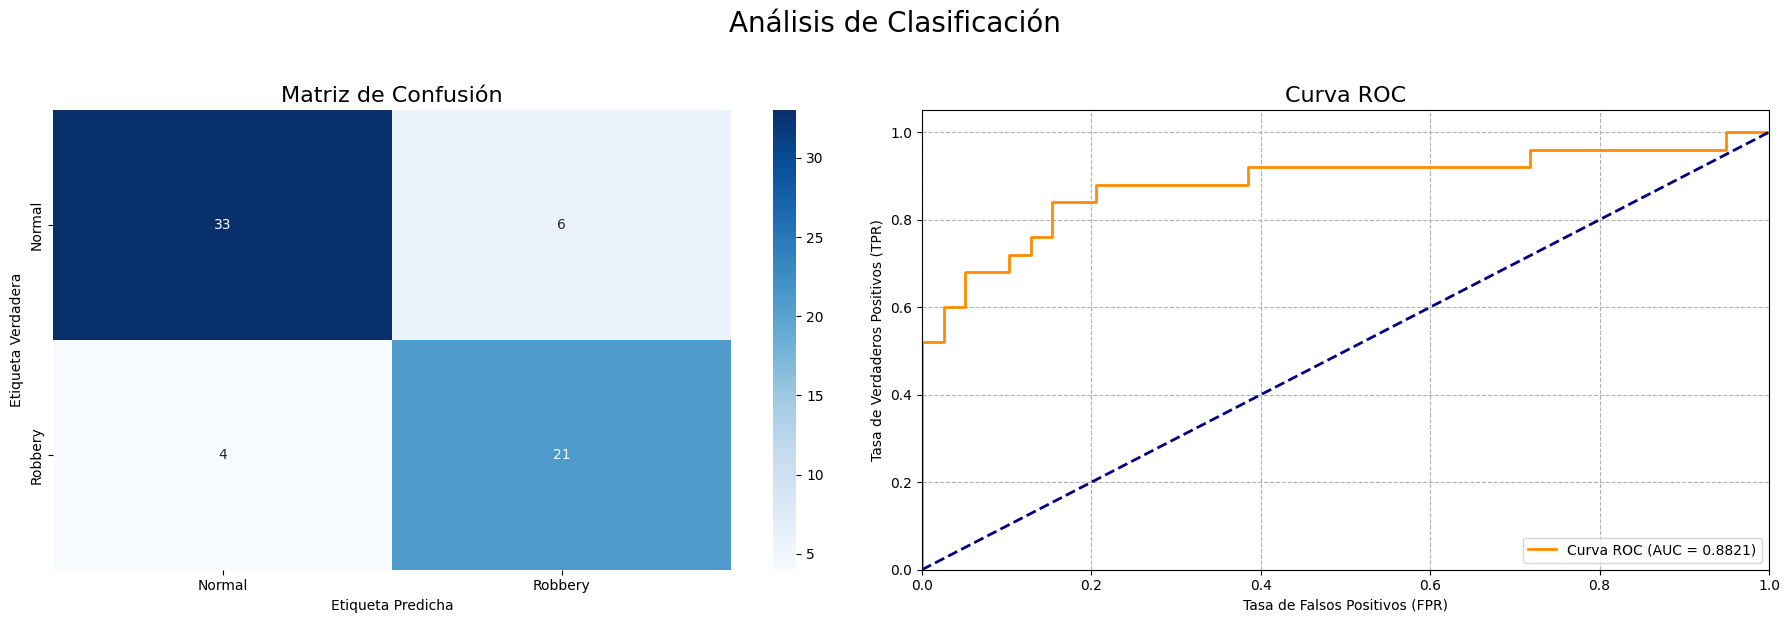

In [25]:
# Cargar gráficos guardados del experimento
plots_dir = BEST_EXP_DIR / 'results' / 'plots'

if plots_dir.exists():
    plot_files = list(plots_dir.glob('*.png'))
    
    if plot_files:
        display(Markdown("### Gráficos de Análisis"))
        
        for plot_file in sorted(plot_files):
            stem_filename = plot_file.stem
            title = stem_filename
            
            if "1_training_history" in stem_filename:
                title = "Historial de Entrenamiento"
            elif "2_classification_analysis" in stem_filename:
                title = "Análisis de Clasificación"
            elif "3_predictions_analysis" in stem_filename:
                title = "Análisis de Predicciones"
            
            display(Markdown(f"#### {title}"))
            display(Image(filename=str(plot_file), width=900))
            print()
    else:
        print("No se encontraron gráficos guardados.")
else:
    print("No existe el directorio de plots.")

## 6. Análisis de Predicciones

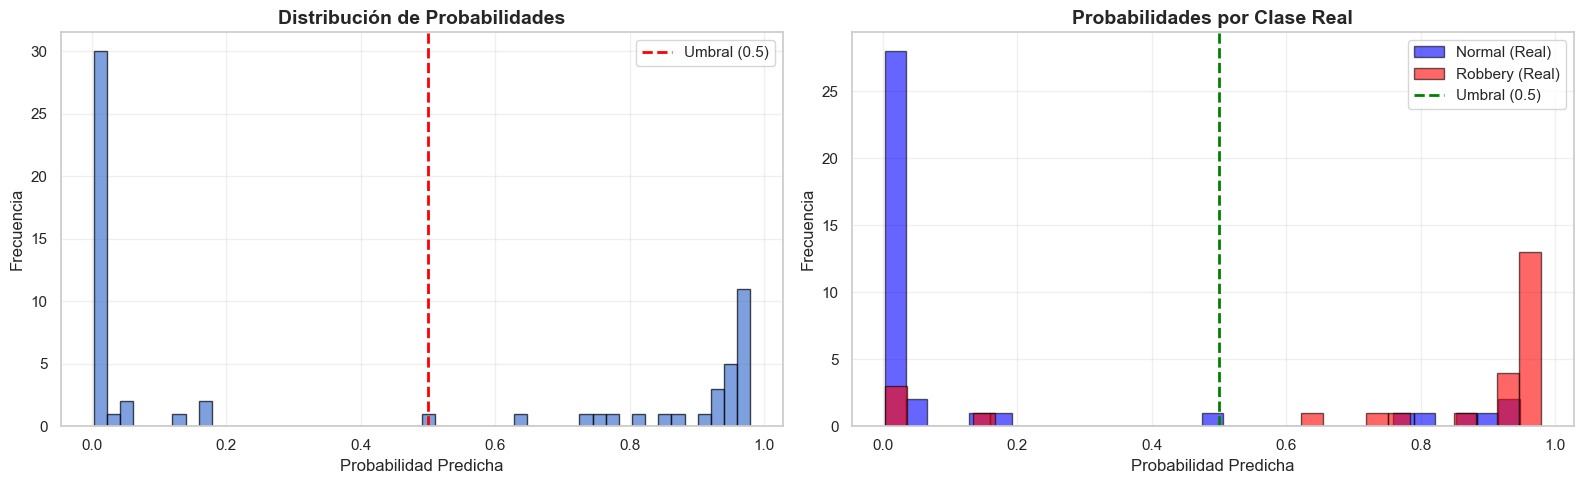

### Estadísticas de Probabilidades Predichas

,Clase Real,Media,Desv. Std,Min,Max
0,Normal,0.1634,0.3155,0.0025,0.9469
1,Robbery,0.7808,0.3323,0.0034,0.9791
2,General,0.4046,0.4411,0.0025,0.9791


In [26]:
if preds_path.exists():
    y_probs = np.array(predictions['probs'])
    
    # Distribución de probabilidades predichas
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Histograma general
    axes[0].hist(y_probs, bins=50, edgecolor='black', alpha=0.7)
    axes[0].axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Umbral (0.5)')
    axes[0].set_xlabel('Probabilidad Predicha', fontsize=12)
    axes[0].set_ylabel('Frecuencia', fontsize=12)
    axes[0].set_title('Distribución de Probabilidades', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Distribución por clase real
    probs_normal = y_probs[np.array(y_true) == 0]
    probs_robbery = y_probs[np.array(y_true) == 1]
    
    axes[1].hist(probs_normal, bins=30, alpha=0.6, label='Normal (Real)', color='blue', edgecolor='black')
    axes[1].hist(probs_robbery, bins=30, alpha=0.6, label='Robbery (Real)', color='red', edgecolor='black')
    axes[1].axvline(x=0.5, color='green', linestyle='--', linewidth=2, label='Umbral (0.5)')
    axes[1].set_xlabel('Probabilidad Predicha', fontsize=12)
    axes[1].set_ylabel('Frecuencia', fontsize=12)
    axes[1].set_title('Probabilidades por Clase Real', fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Estadísticas de probabilidades
    display(Markdown("### Estadísticas de Probabilidades Predichas"))
    stats_data = {
        'Clase Real': ['Normal', 'Robbery', 'General'],
        'Media': [probs_normal.mean(), probs_robbery.mean(), y_probs.mean()],
        'Desv. Std': [probs_normal.std(), probs_robbery.std(), y_probs.std()],
        'Min': [probs_normal.min(), probs_robbery.min(), y_probs.min()],
        'Max': [probs_normal.max(), probs_robbery.max(), y_probs.max()]
    }
    df_stats = pd.DataFrame(stats_data)
    display(df_stats.style.format({
        'Media': '{:.4f}',
        'Desv. Std': '{:.4f}',
        'Min': '{:.4f}',
        'Max': '{:.4f}'
    }))

## 7. Empaquetado del Modelo

In [27]:
# Crear directorio
results_dir = Path('../results/inference')
results_dir.mkdir(parents=True, exist_ok=True)

display(Markdown(f"### Empaquetando Modelo Híbrido en `{results_dir}`"))

# Copiar modelo LSTM entrenado
model_src = BEST_EXP_DIR / 'results' / 'models' / 'best_lstm_model.pth'
model_dst = results_dir / 'lstm_model.pth'

if model_src.exists():
    import shutil
    shutil.copy2(model_src, model_dst)
    print(f"Modelo LSTM copiado a: {model_dst.resolve()}")
else:
    print("No se encontró el modelo LSTM entrenado.")

# Determinar tipo de extractor usado
features_used = final_metrics.get('features_used', 'r3d')
feature_dim = best_hyperparams.get('input_size', 512)

print(f"\nTipo de extractor detectado: {features_used}")
print(f"   Dimensión de features: {feature_dim}")

# Guardar configuración del modelo híbrido
model_config = {
    'experiment_name': BEST_EXPERIMENT,
    'hybrid_architecture': {
        'feature_extractor': {
            'type': 'r3d',
            'backbone': 'R3D-18 (3D ResNet-18)',
            'pretrained_weights': 'Kinetics-400',
            'output_dim': feature_dim,
            'clip_length': 16,
            'frame_size': [112, 112]
        },
        'classifier': {
            'type': 'LSTM',
            'input_size': feature_dim,
            'hidden_size': best_hyperparams.get('hidden_size'),
            'num_layers': best_hyperparams.get('num_layers'),
            'bidirectional': best_hyperparams.get('bidirectional'),
            'dropout_fc': best_hyperparams.get('dropout_fc'),
            'use_attention': best_hyperparams.get('use_attention', True)
        }
    },
    'training_config': {
        'lr': best_hyperparams.get('lr'),
        'weight_decay': best_hyperparams.get('weight_decay'),
        'batch_size': best_hyperparams.get('batch_size')
    },
    'video_processing': config.get('video_processing', {
        'clip_length': 16,
        'max_segments_per_video': 32,
        'overlapping': True,
        'stride': 8
    }),
    'performance_metrics': test_metrics,
    'class_names': CLASS_NAMES,
    'threshold': 0.5,
    'preprocessing': {
        'normalize_mean': [0.43216, 0.394666, 0.37645],
        'normalize_std': [0.22803, 0.22145, 0.216989],
        'resize': [112, 112]
    }
}

config_dst = results_dir / 'model_config.json'
with open(config_dst, 'w', encoding='utf-8') as f:
    json.dump(model_config, f, indent=4)
print(f"Configuración guardada en: {config_dst.resolve()}")

# Copiar código fuente necesario
print("\nCopiando código fuente...")
src_dir = results_dir / 'src'
src_dir.mkdir(exist_ok=True)

lstm_src = Path('../src/models/lstm_classifier.py')
lstm_dst = src_dir / 'lstm_classifier.py'
if lstm_src.exists():
    shutil.copy2(lstm_src, lstm_dst)
    print(f"lstm_classifier.py copiado")

# Crear script de inferencia end-to-end
inference_script = '''
import torch
import torch.nn as nn
import numpy as np
import json
import cv2
from pathlib import Path
from torchvision import transforms
from torchvision.models.video import r3d_18, R3D_18_Weights
from PIL import Image
try:
    from src.lstm_classifier import LSTMClassifier
except ImportError:
    import sys
    sys.path.append(str(Path(__file__).parent))
    from src.lstm_classifier import LSTMClassifier

class HybridRobberyDetector(nn.Module):
    """
    Modelo híbrido end-to-end para detección de robos.
    Combina R3D-18 (extractor de características) + LSTM (clasificador).
    Incluye explicabilidad (XAI) mediante el mecanismo de atención del LSTM.
    """
    def __init__(self, config):
        super(HybridRobberyDetector, self).__init__()
        self.config = config
        
        # Feature Extractor: R3D-18 sin FC layer
        self.feature_extractor = self._build_feature_extractor()
        
        # Classifier: LSTM
        classifier_config = config['hybrid_architecture']['classifier']
        self.classifier = LSTMClassifier(
            input_size=classifier_config['input_size'],
            hidden_size=classifier_config['hidden_size'],
            num_layers=classifier_config['num_layers'],
            bidirectional=classifier_config['bidirectional'],
            dropout_fc=classifier_config['dropout_fc'],
            use_attention=classifier_config.get('use_attention', True)
        )
        
        # Preprocessing
        preproc = config['preprocessing']
        self.transform = transforms.Compose([
            transforms.Resize(tuple(preproc['resize'])),
            transforms.ToTensor(),
            transforms.Normalize(mean=preproc['normalize_mean'], std=preproc['normalize_std'])
        ])
    
    def _build_feature_extractor(self):
        """Construye el extractor R3D-18 sin la capa FC."""
        weights = R3D_18_Weights.DEFAULT
        model = r3d_18(weights=weights)
        model.fc = nn.Identity()  # Eliminar fully connected layer
        
        # Congelar parámetros (opcional, para inferencia)
        for param in model.parameters():
            param.requires_grad = False
        
        return model
    
    def forward(self, clip_features):
        """
        Forward pass a través de LSTM.
        
        Args:
            clip_features: Tensor de shape (batch, n_clips, feature_dim)
        
        Returns:
            Probabilidad de robo (batch,)
        """
        return self.classifier(clip_features)


class RobberyDetector:
    """
    Interfaz de alto nivel para detección de robos en videos, con explicabilidad.
    """
    def __init__(self, model_dir='results/inference'):
        self.model_dir = Path(model_dir)
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
        # Cargar configuración
        with open(self.model_dir / 'model_config.json', 'r') as f:
            self.config = json.load(f)
        
        # Cargar modelo híbrido
        self.model = self._load_hybrid_model()
        self.threshold = self.config['threshold']
    
    def _load_hybrid_model(self):
        """Carga el modelo híbrido completo."""
        model = HybridRobberyDetector(self.config).to(self.device)
        
        # Cargar pesos de LSTM
        lstm_weights = torch.load(self.model_dir / 'lstm_model.pth', map_location=self.device)
        model.classifier.load_state_dict(lstm_weights)
        
        model.eval()
        return model
    
    def predict_from_features(self, features):
        """
        Predice a partir de features pre-extraídos.
        """
        with torch.no_grad():
            features_tensor = torch.tensor(features, dtype=torch.float32).unsqueeze(0).to(self.device)
            output = self.model(features_tensor)
            prob = output.item()
            
            # Obtener pesos de atención para XAI
            attention = self.model.classifier.get_attention_weights()
            if attention is not None:
                attn_weights = attention.squeeze(0).cpu().numpy()
                most_important_clip = int(np.argmax(attn_weights))
            else:
                attn_weights = None
                most_important_clip = None
        
        is_robbery = prob >= self.threshold
        class_name = self.config['class_names'][1] if is_robbery else self.config['class_names'][0]
        
        return {
            'class': class_name,
            'probability': prob,
            'is_robbery': is_robbery,
            'attention_weights': attn_weights,
            'most_important_clip_idx': most_important_clip
        }
    
    def predict_from_video(self, video_path):
        """
        Inferencia completa sobre un archivo de video. 
        Aplica procesamiento (extraccion de clips a intervalos segun config de entrenamiento), 
        lo pasa por el extractor R3D_18 para sacar features y finalmente predice con la LSTM.
        Muestra en que segundo ocurrio la situacion mas riesgosa si la clase detectada es Robbery.
        
        Args:
            video_path: Ruta al archivo de video (.mp4)
            
        Returns:
            dict: Resultados con predicción, probabilidades y momento detonante (XAI)
        """
        video_path = str(video_path)
        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            raise ValueError(f"No se pudo abrir el video: {video_path}")
            
        fps = cap.get(cv2.CAP_PROP_FPS)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        
        vp_config = self.config.get('video_processing', {})
        clip_length = vp_config.get('clip_length', 16)
        stride = vp_config.get('stride', 8)
        overlapping = vp_config.get('overlapping', True)
        
        # Calcular los intervalos de cada clip simulando el dataset
        clip_intervals = []
        if overlapping:
            start = 0
            while start + clip_length <= total_frames:
                clip_intervals.append((start, start + clip_length))
                start += stride
            if not clip_intervals and total_frames > 0:
                clip_intervals.append((0, total_frames))
        else:
            max_segments = vp_config.get('max_segments_per_video', 32)
            if total_frames > clip_length:
                for i in range(max_segments):
                    start_idx = int(i * (total_frames - clip_length) / max_segments)
                    clip_intervals.append((start_idx, start_idx + clip_length))
            else:
                clip_intervals.append((0, total_frames if total_frames > 0 else 1))

        # Extraer frames, transform y guardar
        clips_tensors = []
        clip_timestamps = [] # Store time in seconds (start, end)
        
        for start, end in clip_intervals:
            cap.set(cv2.CAP_PROP_POS_FRAMES, start)
            frames = []
            for _ in range(end - start):
                ret, frame = cap.read()
                if not ret: 
                    break
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frame = Image.fromarray(frame)
                frames.append(self.model.transform(frame))
            
            if not frames: 
                continue
                
            # Pad si faltan frames
            while len(frames) < clip_length:
                frames.append(frames[-1])
            
            # Formato tensor r3d_18: (3, clip_len, H, W)
            clip_tensor = torch.stack(frames, dim=1)
            clips_tensors.append(clip_tensor)
            
            start_sec = start / fps if fps else 0
            end_sec = end / fps if fps else 0
            clip_timestamps.append((start_sec, end_sec))
            
        cap.release()
        
        if not clips_tensors:
            raise ValueError("No se pudieron extraer clips válidos de este video.")

        # Batch features extraction en bloques para no llenar memoria
        clips_batch = torch.stack(clips_tensors)
        batch_size = 16
        features_list = []
        
        with torch.no_grad():
            from tqdm import tqdm
            print(f"Extrayendo características de {len(clips_batch)} clips...")
            for i in range(0, len(clips_batch), batch_size):
                batch_features = self.model.feature_extractor(clips_batch[i:i+batch_size].to(self.device))
                features_list.append(batch_features.cpu())
                
        features = torch.cat(features_list, dim=0).numpy()
        
        # Inferencia con la red LSTM
        result = self.predict_from_features(features)
        
        # Integrar las marcas de tiempo en segundos (XAI)
        result['clip_timestamps'] = clip_timestamps
        most_important_idx = result['most_important_clip_idx']
        
        if most_important_idx is not None and most_important_idx < len(clip_timestamps):
            trigger_time = clip_timestamps[most_important_idx]
            result['trigger_time_seconds'] = trigger_time
            if result['is_robbery']:
                result['xai_message'] = f"Robo mayormente detectado entre los segundos {trigger_time[0]:.2f}s y {trigger_time[1]:.2f}s (Clip {most_important_idx})"
            else:
                result['xai_message'] = f"No se detectó ningún robo."
        else:
            result['trigger_time_seconds'] = None
            result['xai_message'] = "No se pudo determinar el momento de mayor alerta."
            
        return result
    
    def get_model_info(self):
        """Retorna información del modelo."""
        return {
            'experiment': self.config['experiment_name'],
            'architecture': self.config['hybrid_architecture'],
            'metrics': self.config['performance_metrics']
        }


# Ejemplo de uso
if __name__ == "__main__":
    import os
    print("=" * 50)
    print("Robbery Detection - Full Video Inference (XAI)")
    print("=" * 50)
    
    detector = RobberyDetector(model_dir=os.path.dirname(os.path.abspath(__file__)))
    info = detector.get_model_info()
    
    print(f"\\nExperimento: {info['experiment']}")
    print(f"Feature Extractor: {info['architecture']['feature_extractor']['backbone']}")
    print(f"Classifier: {info['architecture']['classifier']['type']} (Atención Habilitada: {info['architecture']['classifier'].get('use_attention', True)})")
    
    # Simulación de Inferencia a un video completo. 
    print("\\n" + "=" * 50)
    print("Ejemplo: Predicción de Video End-to-End")
    print("=" * 50)
    print("Para probar desde tu consola ejecuta:\\n")
    print(">>> from inference import RobberyDetector")
    print(">>> detector = RobberyDetector(model_dir='.')")
    print(">>> resultado = detector.predict_from_video('ruta_al_video.mp4')")
    print(">>> print(resultado['class'], resultado['xai_message'])\\n")
'''

inference_dst = results_dir / 'inference.py'
with open(inference_dst, 'w', encoding='utf-8') as f:
    f.write(inference_script)
print(f"Script de inferencia híbrida creado en: {inference_dst.resolve()}")

#Crear README
readme_content = f'''
# Modelo Híbrido de Detección de Robos (XAI) - {BEST_EXPERIMENT}

## Arquitectura del Modelo

Este es un modelo **híbrido end-to-end** que combina:

1. **Feature Extractor: R3D-18 (3D ResNet-18)**
   - Pre-entrenado en Kinetics-400
   - Sin capa fully connected (extrae features de {feature_dim} dimensiones)
   - Input: Clips de video (16 frames de 112x112)
   - Output: Vector de features por clip

2. **Classifier: LSTM Bidireccional con Atención (XAI)**
   - Input Size: {best_hyperparams.get('input_size', 512)}
   - Hidden Size: {best_hyperparams.get('hidden_size')}
   - Num Layers: {best_hyperparams.get('num_layers')}
   - Bidirectional: {best_hyperparams.get('bidirectional')}
   - Dropout: {best_hyperparams.get('dropout_fc')}
   - Mecanismo de Atención Temporal: Calcula la importancia de cada clip en la decisión.

**Pipeline completo:** Video Puro -> Slicing de Clips Automático -> R3D-18 (Features) -> LSTM -> Predicción Final y Respuesta Temporal (XAI)

## Inteligencia Artificial Explicable (XAI)

El modelo cuenta con explicabilidad provista por una capa de **Atención Temporal** a la salida del LSTM. 
Esta capa infiere un peso que refleja la contribución e importancia de ese clip temporal respecto a toda la secuencia evaluada. 
Esto permite que el modelo procese el video competo desde crudo y entregue una predicción y **el intervalo exacto de segundos que representó la mayor sospecha de robo.**

## Métricas de Rendimiento (Test Set)

- **Accuracy:** {test_metrics.get('accuracy', 0):.4f}
- **Precision:** {test_metrics.get('precision', 0):.4f}
- **Recall:** {test_metrics.get('recall', 0):.4f}
- **F1-Score:** {test_metrics.get('f1_score', 0):.4f}
- **AUC-ROC:** {test_metrics.get('auc', 0):.4f}

## Uso End-to-End

```python
from inference import RobberyDetector

# Inicializar detector
# Asegurarse de estar en el directorio de `results/inference` o pasar la ruta en `model_dir`
detector = RobberyDetector(model_dir='.')

# Hacer inferencia inyectando directamente todo el video MP4
result = detector.predict_from_video('video_captura_01.mp4')

print(f"Predicción Final: {{result['class']}}")
print(f"Probabilidad de ser robo: {{result['probability']*100:.2f}}%")

if result['is_robbery']:
    print(f"¡Alerta de Robo detectada!")
    
# Mensaje XAI con el intervalo de tiempo exacto que detonó la decisión
print(f"Explicabilidad: {{result['xai_message']}}")
```

## Estructura de Archivos

```
results/
└── inference/
    ├── lstm_model.pth             # Pesos del clasificador LSTM
    ├── model_config.json          # Configuración completa del modelo híbrido y procesamiento de videos
    ├── inference.py               # Script de inferencia end-to-end
    ├── hybrid_model_complete.pth  # Modelo completo empaquetado (opcional)
    ├── src/
    │   └── lstm_classifier.py     # Definición de la arquitectura con Mecanismo de Atención
    └── README.md                  # Esta documentación
```
'''

readme_dst = results_dir / 'README.md'
with open(readme_dst, 'w', encoding='utf-8') as f:
    f.write(readme_content)
print(f"README creado en: {readme_dst.resolve()}")

# Guardar modelo híbrido completo en un solo archivo
print("\nGuardando modelo híbrido completo...")

try:
    from src.models.lstm_classifier import LSTMClassifier
    from torchvision.models.video import r3d_18, R3D_18_Weights
    import torch.nn as nn
    
    # Crear modelo completo en modo eval
    class HybridModel(nn.Module):
        def __init__(self, lstm_config):
            super().__init__()
            # R3D-18 feature extractor
            weights = R3D_18_Weights.DEFAULT
            self.feature_extractor = r3d_18(weights=weights)
            self.feature_extractor.fc = nn.Identity()
            
            # LSTM classifier
            self.classifier = LSTMClassifier(**lstm_config)
        
        def forward(self, clip_features):
            return self.classifier(clip_features)
    
    # Instanciar y cargar pesos
    hybrid_model = HybridModel({
        'input_size': best_hyperparams.get('input_size', 512),
        'hidden_size': best_hyperparams.get('hidden_size'),
        'num_layers': best_hyperparams.get('num_layers'),
        'bidirectional': best_hyperparams.get('bidirectional'),
        'dropout_fc': best_hyperparams.get('dropout_fc'),
        'use_attention': best_hyperparams.get('use_attention', True)
    })
    
    # Cargar pesos del LSTM
    lstm_state = torch.load(model_src, map_location='cpu')
    hybrid_model.classifier.load_state_dict(lstm_state)
    hybrid_model.eval()
    
    # Guardar modelo completo
    hybrid_dst = results_dir / 'hybrid_model_complete.pth'
    torch.save({
        'hybrid_state_dict': hybrid_model.state_dict(),
        'config': model_config,
        'class_names': CLASS_NAMES
    }, hybrid_dst)
    
    print(f"Modelo híbrido completo guardado en: {hybrid_dst.resolve()}")
except Exception as e:
    print(f"No se pudo crear modelo híbrido completo: {e}")

display(Markdown(f"""
### Empaquetado Completo del Modelo Híbrido (XAI)

**Directorio de producción:** `{results_dir.resolve()}`

**Archivos generados:**
1. `lstm_model.pth` - Pesos del clasificador LSTM entrenado
2. `model_config.json` - Configuración completa del modelo híbrido + Video Processing
3. `inference.py` - Script de inferencia end-to-end
4. `src/lstm_classifier.py` - Definición de la arquitectura LSTM y mecanismo de XAI
5. `hybrid_model_complete.pth` - Modelo completo empaquetado (R3D + LSTM)
6. `README.md` - Documentación completa
"""))


### Empaquetando Modelo Híbrido en `..\results\inference`

Modelo LSTM copiado a: D:\Dataset\results\inference\lstm_model.pth

Tipo de extractor detectado: r3d
   Dimensión de features: 512
Configuración guardada en: D:\Dataset\results\inference\model_config.json

Copiando código fuente...
lstm_classifier.py copiado
Script de inferencia híbrida creado en: D:\Dataset\results\inference\inference.py
README creado en: D:\Dataset\results\inference\README.md

Guardando modelo híbrido completo...
Modelo híbrido completo guardado en: D:\Dataset\results\inference\hybrid_model_complete.pth



### Empaquetado Completo del Modelo Híbrido (XAI)

**Directorio de producción:** `D:\Dataset\results\inference`

**Archivos generados:**
1. `lstm_model.pth` - Pesos del clasificador LSTM entrenado
2. `model_config.json` - Configuración completa del modelo híbrido + Video Processing
3. `inference.py` - Script de inferencia end-to-end
4. `src/lstm_classifier.py` - Definición de la arquitectura LSTM y mecanismo de XAI
5. `hybrid_model_complete.pth` - Modelo completo empaquetado (R3D + LSTM)
6. `README.md` - Documentación completa


## 8. Generación de Reporte HTML


In [28]:
import base64
import io
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from pathlib import Path

# Definir ruta para el reporte en formato HTML
html_report_path = Path('../results/best_model/best_model_report.html')
html_report_path.parent.mkdir(parents=True, exist_ok=True)

# Generación de gráficos y tablas

vp_conf = config.get('video_processing', {})

# Formatear split_ratios
sr = vp_conf.get('split_ratios', 'N/A')
if isinstance(sr, list) and len(sr) == 3:
    split_ratios_str = f"Train: {int(sr[0]*100)}% - Validation: {int(sr[1]*100)}% - Test: {int(sr[2]*100)}%"
else:
    split_ratios_str = str(sr)

preproc_params = {
    'clip_length': vp_conf.get('clip_length', 16),
    'max_segments_per_video': vp_conf.get('max_segments_per_video', 32),
    'overlapping': vp_conf.get('overlapping', True),
    'stride': vp_conf.get('stride', 8),
    'balance_max_ratio': vp_conf.get('balance_max_ratio', 'N/A'),
    'split_ratios': split_ratios_str,
    'input_size': best_hyperparams.get('input_size', 512)
}

# Tabla de Optuna HTML y Gráfico
optuna_html = ""
optuna_b64 = ""
optuna_results_path = BEST_EXP_DIR / 'results' / 'tables' / 'optuna_lstm_trials.csv'
if optuna_results_path.exists():
    df_optuna = pd.read_csv(optuna_results_path)
    top_trials = df_optuna.nsmallest(10, 'value')[['number', 'value', 'params_hidden_size', 'params_num_layers', 'params_bidirectional', 'params_dropout_fc', 'params_lr', 'params_weight_decay', 'params_batch_size']]
    # Rename cols for a cleaner table
    top_trials.columns = [col.replace('params_', '') for col in top_trials.columns]
    optuna_html = top_trials.to_html(index=False, classes="table", border=0).replace('class="dataframe table"', 'class="table"')
    
    fig_opt, axes_opt = plt.subplots(1, 2, figsize=(16, 5))
    completed_trials = df_optuna[df_optuna['state'] == 'COMPLETE']
    axes_opt[0].plot(completed_trials['number'], completed_trials['value'], 'o-', alpha=0.6, label='Trial value')
    axes_opt[0].plot(completed_trials['number'], completed_trials['value'].cummin(), 'r-', linewidth=2, label='Best value')
    axes_opt[0].set_xlabel('Trial Number')
    axes_opt[0].set_ylabel('Validation Loss')
    axes_opt[0].set_title('Optimización de Hiperparámetros')
    axes_opt[0].legend()
    axes_opt[0].grid(True, alpha=0.3)
    
    axes_opt[1].hist(completed_trials['value'], bins=30, edgecolor='black', alpha=0.7)
    axes_opt[1].axvline(completed_trials['value'].min(), color='red', linestyle='--', linewidth=2, label='Mejor valor')
    axes_opt[1].set_xlabel('Validation Loss')
    axes_opt[1].set_ylabel('Frecuencia')
    axes_opt[1].set_title('Distribución de Resultados')
    axes_opt[1].legend()
    axes_opt[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    buf_opt = io.BytesIO()
    fig_opt.savefig(buf_opt, format='png', bbox_inches='tight')
    plt.close(fig_opt)
    optuna_b64 = base64.b64encode(buf_opt.getvalue()).decode()

# Gráficos de Scatter Plots y Coordenadas Paralelas para la Sección 2
scatter_plots_b64 = ""
parallel_coords_b64 = ""

try:
    # Scatter plots de todos los hiperparámetros
    fig_scatter, axes_scatter = plt.subplots(2, 4, figsize=(22, 10))
    axes_scatter = axes_scatter.flatten()
    
    plot_configs = [
        (0, 'params_lr', 'Learning Rate', 'lightblue', '#e74c3c', 'Learning Rate'),
        (1, 'params_dropout_fc', 'Dropout', 'lightgreen', '#27ae60', 'Dropout (FC)'),
        (2, 'params_weight_decay', 'Weight Decay', 'lightyellow', '#f39c12', 'Weight Decay'),
        (3, 'params_batch_size', 'Batch Size', '#e8f4f8', '#2563eb', 'Batch Size'),
        (4, 'params_hidden_size', 'Hidden Size', '#e0f2fe', '#0284c7', 'Hidden Size'),
        (5, 'params_num_layers', 'Num Layers', '#fef3c7', '#d97706', 'Num Layers'),
        (6, 'params_bidirectional', 'Bidirectional', '#dbeafe', '#059669', 'Bidirectional'),
    ]
    
    # Preparar datos renombrados para scatter plots
    scatter_data = df_optuna[df_optuna['state'] == 'COMPLETE'].copy()
    param_renames = {
        'params_batch_size': 'Batch Size',
        'params_bidirectional': 'Bidirectional',
        'params_dropout_fc': 'Dropout',
        'params_hidden_size': 'Hidden Size',
        'params_lr': 'Learning Rate',
        'params_num_layers': 'Num Layers',
        'params_weight_decay': 'Weight Decay'
    }
    scatter_data = scatter_data.rename(columns=param_renames)
    
    top10_scatter = top_trials.copy()
    # Renombrar los parámetros de top10_scatter (que ya tienen formato sin 'params_')
    top10_renames = {
        'batch_size': 'Batch Size',
        'bidirectional': 'Bidirectional',
        'dropout_fc': 'Dropout',
        'hidden_size': 'Hidden Size',
        'lr': 'Learning Rate',
        'num_layers': 'Num Layers',
        'weight_decay': 'Weight Decay'
    }
    top10_scatter = top10_scatter.rename(columns=top10_renames)
    
    for idx, param, label, color_light, color_top, title in plot_configs:
        ax = axes_scatter[idx]
        
        if label == 'Bidirectional':
            all_param_numeric = scatter_data[label].astype(int)
            top10_param_numeric = top10_scatter[label].map({'Yes': 1, 'No': 0, True: 1, False: 0}).astype(int)
            
            ax.scatter(all_param_numeric + np.random.normal(0, 0.02, len(all_param_numeric)), 
                      scatter_data['value'], 
                      alpha=0.6, s=100, c=color_light, edgecolors='gray', linewidth=1, label='Otros Trials')
            ax.scatter(top10_param_numeric + np.random.normal(0, 0.02, len(top10_param_numeric)), 
                      top10_scatter['value'], 
                      alpha=0.9, s=200, c=color_top, edgecolors='black', linewidth=2, label='Top-10 Trials', zorder=5)
            ax.set_xticks([0, 1])
            ax.set_xticklabels(['No', 'Yes'])
        else:
            ax.scatter(scatter_data[label], scatter_data['value'], 
                      alpha=0.6, s=100, c=color_light, edgecolors='gray', linewidth=1, label='Otros Trials')
            ax.scatter(top10_scatter[label], top10_scatter['value'], 
                      alpha=0.9, s=200, c=color_top, edgecolors='black', linewidth=2, label='Top-10 Trials', zorder=5)
        
        ax.set_xlabel(title, fontsize=11, fontweight='bold')
        ax.set_ylabel('Loss de Validación', fontsize=11, fontweight='bold')
        ax.set_title(f'Impacto del {title}', fontsize=12, fontweight='bold', pad=12)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9, loc='best')
    
    fig_scatter.delaxes(axes_scatter[7])
    fig_scatter.suptitle('Análisis Integral: Relación entre Hiperparámetros y Loss de Validación', 
                         fontsize=15, fontweight='bold', y=0.995)
    fig_scatter.tight_layout()
    
    buf_scatter = io.BytesIO()
    fig_scatter.savefig(buf_scatter, format='png', bbox_inches='tight')
    plt.close(fig_scatter)
    scatter_plots_b64 = base64.b64encode(buf_scatter.getvalue()).decode()
    
    # Parallel Coordinates Plot
    fig_parallel, ax_parallel = plt.subplots(figsize=(16, 8))
    
    params_to_include = ['Batch Size', 'Hidden Size', 'Num Layers', 'Dropout', 'Learning Rate', 'Weight Decay']
    
    normalized_data = {}
    for param in params_to_include:
        values = top10_scatter[param].values
        min_val = values.min()
        max_val = values.max()
        
        if max_val > min_val:
            normalized_data[param] = (values - min_val) / (max_val - min_val)
        else:
            normalized_data[param] = np.ones_like(values) * 0.5
    
    num_params = len(params_to_include)
    num_trials = len(top10_scatter)
    
    loss_values = top10_scatter['value'].values
    loss_normalized = (loss_values - loss_values.min()) / (loss_values.max() - loss_values.min())
    colors = plt.cm.RdYlGn_r(loss_normalized)
    
    for trial_idx in range(num_trials):
        y_values = [normalized_data[param][trial_idx] for param in params_to_include]
        ax_parallel.plot(range(num_params), y_values, color=colors[trial_idx], alpha=0.7, linewidth=2.5, zorder=1)
        ax_parallel.scatter(range(num_params), y_values, color=colors[trial_idx], s=100, 
                           edgecolors='black', linewidth=1, zorder=2, alpha=0.8)
    
    ax_parallel.set_xticks(range(num_params))
    ax_parallel.set_xticklabels(params_to_include, fontsize=12, fontweight='bold')
    ax_parallel.set_ylabel('Valor Normalizado (0-1)', fontsize=12, fontweight='bold')
    ax_parallel.set_ylim([-0.1, 1.1])
    ax_parallel.set_xlim([-0.5, num_params - 0.5])
    
    for x in range(num_params):
        ax_parallel.axvline(x=x, color='gray', linestyle='--', alpha=0.3, linewidth=1)
    
    ax_parallel.set_title('Gráfico de Coordenadas Paralelas: Cómo se Combinan los Hiperparámetros en Top-10 Trials\n' + 
                         'Color de línea: Rojo=Peor Loss → Verde=Mejor Loss', 
                         fontsize=14, fontweight='bold', pad=20)
    ax_parallel.grid(axis='y', alpha=0.3)
    
    fig_parallel.tight_layout()
    buf_parallel = io.BytesIO()
    fig_parallel.savefig(buf_parallel, format='png', bbox_inches='tight')
    plt.close(fig_parallel)
    parallel_coords_b64 = base64.b64encode(buf_parallel.getvalue()).decode()
    
except Exception as e:
    print(f"Error generando gráficos de scatter plots y coordenadas paralelas: {e}")

# Gráfico Training Hist truncado
hist_b64 = ""
history_path = BEST_EXP_DIR / 'results' / 'tables' / 'lstm_training_history.json'
if history_path.exists():
    with open(history_path, 'r') as fh:
        history = json.load(fh)
    
    best_ep = final_metrics.get('best_epoch', 1)
    limit = best_ep + 1
    epochs = list(range(1, limit + 1))
    
    max_len = len(history['train_loss'])
    if limit > max_len:
        limit = max_len
        epochs = list(range(1, limit + 1))
        
    fig_hist, axes_h = plt.subplots(2, 3, figsize=(18, 10))
    
    axes_h[0, 0].plot(epochs, history['train_loss'][:limit], 'b-', label='Train Loss', linewidth=2)
    axes_h[0, 0].plot(epochs, history['val_loss'][:limit], 'r-', label='Val Loss', linewidth=2)
    axes_h[0, 0].set_xlabel('Epoch')
    axes_h[0, 0].set_ylabel('Loss')
    axes_h[0, 0].set_title('Pérdida (Train vs Val)')
    axes_h[0, 0].legend()
    axes_h[0, 0].grid(True, alpha=0.3)
    
    axes_h[0, 1].plot(epochs, history['val_auc'][:limit], 'g-', linewidth=2)
    axes_h[0, 1].set_xlabel('Epoch')
    axes_h[0, 1].set_ylabel('AUC')
    axes_h[0, 1].set_title('AUC en Validación')
    axes_h[0, 1].grid(True, alpha=0.3)
    
    axes_h[0, 2].plot(epochs, history['val_accuracy'][:limit], 'purple', linewidth=2)
    axes_h[0, 2].set_xlabel('Epoch')
    axes_h[0, 2].set_ylabel('Accuracy')
    axes_h[0, 2].set_title('Accuracy en Validación')
    axes_h[0, 2].grid(True, alpha=0.3)
    
    axes_h[1, 0].plot(epochs, history['val_precision'][:limit], 'orange', linewidth=2)
    axes_h[1, 0].set_xlabel('Epoch')
    axes_h[1, 0].set_ylabel('Precision')
    axes_h[1, 0].set_title('Precision en Validación')
    axes_h[1, 0].grid(True, alpha=0.3)
    
    axes_h[1, 1].plot(epochs, history['val_recall'][:limit], 'brown', linewidth=2)
    axes_h[1, 1].set_xlabel('Epoch')
    axes_h[1, 1].set_ylabel('Recall')
    axes_h[1, 1].set_title('Recall en Validación')
    axes_h[1, 1].grid(True, alpha=0.3)
    
    axes_h[1, 2].plot(epochs, history['val_f1_score'][:limit], 'teal', linewidth=2)
    axes_h[1, 2].set_xlabel('Epoch')
    axes_h[1, 2].set_ylabel('F1-Score')
    axes_h[1, 2].set_title('F1-Score en Validación')
    axes_h[1, 2].grid(True, alpha=0.3)
    
    for ax in axes_h.flat:
        ax.axvline(x=best_ep, color='red', linestyle='--', alpha=0.7, linewidth=1.5)
        
    plt.tight_layout()
    buf_hist = io.BytesIO()
    fig_hist.savefig(buf_hist, format='png', bbox_inches='tight')
    plt.close(fig_hist)
    hist_b64 = base64.b64encode(buf_hist.getvalue()).decode()


# Gráfico de Predicciones
pred_b64 = ""
preds_path = BEST_EXP_DIR / 'results' / 'tables' / 'lstm_test_predictions.json'
if preds_path.exists():
    with open(preds_path, 'r') as fp:
        predictions = json.load(fp)
    
    y_trues = predictions['labels']
    y_probs = np.array(predictions['probs'])
    
    fig_pred, axes_p = plt.subplots(1, 2, figsize=(16, 5))
    axes_p[0].hist(y_probs, bins=50, edgecolor='black', alpha=0.7)
    axes_p[0].axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Umbral (0.5)')
    axes_p[0].set_xlabel('Probabilidad Predicha')
    axes_p[0].set_ylabel('Frecuencia')
    axes_p[0].set_title('Distribución de Probabilidades')
    axes_p[0].legend()
    axes_p[0].grid(True, alpha=0.3)
    
    probs_n = y_probs[np.array(y_trues) == 0]
    probs_r = y_probs[np.array(y_trues) == 1]
    
    axes_p[1].hist(probs_n, bins=30, alpha=0.6, label='Normal (Real)', color='blue', edgecolor='black')
    axes_p[1].hist(probs_r, bins=30, alpha=0.6, label='Robbery (Real)', color='red', edgecolor='black')
    axes_p[1].axvline(x=0.5, color='green', linestyle='--', linewidth=2, label='Umbral (0.5)')
    axes_p[1].set_xlabel('Probabilidad Predicha')
    axes_p[1].set_ylabel('Frecuencia')
    axes_p[1].set_title('Probabilidades por Clase Real')
    axes_p[1].legend()
    axes_p[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    buf_pred = io.BytesIO()
    fig_pred.savefig(buf_pred, format='png', bbox_inches='tight')
    plt.close(fig_pred)
    pred_b64 = base64.b64encode(buf_pred.getvalue()).decode()


# template html
html_content = f"""<!DOCTYPE html>
<html lang='es'>
<head>
  <meta charset='utf-8' />
  <meta name='viewport' content='width=device-width, initial-scale=1' />
  <title>Reporte Mejor Modelo - {{BEST_EXPERIMENT}}</title>
  <style>
    :root {{
      --bg: #f7f8fa;
      --card: #ffffff;
      --ink: #1f2937;
      --muted: #6b7280;
      --brand: #1d4ed8;
      --line: #e5e7eb;
      --hero-bg: linear-gradient(135deg, #dbe9f4 0%, #cbd5e1 100%);
      --hero-text: #000000;
      --th-bg: #f3f4f6;
      --highlight-bg: #e0f2fe;
      --highlight-border: #3b82f6;
      --highlight-text: #1d4ed8;
    }}

    html.dark-mode {{
      --bg: #1a1a1a;
      --card: #2a2a2a;
      --ink: #f0f0f0;
      --muted: #a0a0a0;
      --brand: #4a9eff;
      --line: #404040;
      --hero-bg: linear-gradient(135deg, #334155 0%, #1e293b 100%);
      --hero-text: #ffffff;
      --th-bg: #333333;
      --highlight-bg: #1e3a8a;
      --highlight-border: #60a5fa;
      --highlight-text: #bfdbfe;
    }}

    body {{
      margin: 0;
      font-family: 'Segoe UI', Tahoma, sans-serif;
      background: var(--bg);
      color: var(--ink);
      transition: background-color 0.3s, color 0.3s;
    }}

    .container {{
      max-width: 1400px;
      margin: 0 auto;
      padding: 24px;
    }}

    .theme-toggle {{
      position: fixed;
      top: 20px;
      right: 20px;
      z-index: 1000;
      display: flex;
      align-items: center;
      gap: 10px;
    }}

    .toggle-label {{
      font-size: 14px;
      color: var(--muted);
    }}

    .toggle-switch {{
      position: relative;
      width: 60px;
      height: 30px;
      background: var(--line);
      border-radius: 15px;
      cursor: pointer;
      transition: background 0.3s;
      border: 2px solid var(--line);
    }}

    .toggle-switch.active {{
      background: #4a9eff;
      border-color: #4a9eff;
    }}

    .toggle-slider {{
      position: absolute;
      top: 2px;
      left: 2px;
      width: 24px;
      height: 24px;
      background: white;
      border-radius: 50%;
      transition: left 0.3s;
      display: flex;
      align-items: center;
      justify-content: center;
      font-size: 14px;
    }}

    .toggle-switch.active .toggle-slider {{
      left: 32px;
    }}

    .toggle-slider {{
      background-image: url("data:image/svg+xml;utf8,<svg xmlns='http://www.w3.org/2000/svg' viewBox='0 0 24 24' fill='none' stroke='%23FFB81C' stroke-width='2' stroke-linecap='round' stroke-linejoin='round'><circle cx='12' cy='12' r='5'/><line x1='12' y1='1' x2='12' y2='3'/><line x1='12' y1='21' x2='12' y2='23'/><line x1='4.22' y1='4.22' x2='5.64' y2='5.64'/><line x1='18.36' y1='18.36' x2='19.78' y2='19.78'/><line x1='1' y1='12' x2='3' y2='12'/><line x1='21' y1='12' x2='23' y2='12'/><line x1='4.22' y1='19.78' x2='5.64' y2='18.36'/><line x1='18.36' y1='5.64' x2='19.78' y2='4.22'/></svg>");
      background-size: 14px 14px;
      background-repeat: no-repeat;
      background-position: center;
    }}

    .toggle-switch.active .toggle-slider {{
      background-image: url("data:image/svg+xml;utf8,<svg xmlns='http://www.w3.org/2000/svg' viewBox='0 0 24 24' fill='%234B7BE5'><path d='M21 12.79A9 9 0 1 1 11.21 3 7 7 0 0 0 21 12.79z'/></svg>");
      background-size: 14px 14px;
      background-repeat: no-repeat;
      background-position: center;
    }}

    .hero {{
      background: var(--hero-bg);
      color: var(--hero-text);
      border-radius: 14px;
      padding: 24px;
      box-shadow: 0 10px 30px rgba(0,0,0,0.15);
      margin-bottom: 20px;
    }}

    .hero h1 {{ margin: 0 0 10px 0; font-size: 28px; }}
    .hero p {{ margin: 2px 0; opacity: 0.95; }}

    .grid {{
      display: grid;
      grid-template-columns: repeat(auto-fit, minmax(200px, 1fr));
      gap: 12px;
      margin-bottom: 20px;
    }}

    .kpi {{
      background: var(--card);
      border: 1px solid var(--line);
      border-radius: 12px;
      padding: 14px;
      transition: border-color 0.3s, background 0.3s;
    }}

    .kpi .label {{ color: var(--muted); font-size: 12px; text-transform: uppercase; }}
    .kpi .value {{ font-size: 22px; font-weight: 700; margin-top: 6px; }}

    /* Highlight class for top metrics */
    .kpi.highlight {{
      background: var(--highlight-bg);
      border-color: var(--highlight-border);
      border-width: 2px;
    }}
    .kpi.highlight .value {{
      color: var(--highlight-text);
    }}

    .card {{
      background: var(--card);
      border: 1px solid var(--line);
      border-radius: 12px;
      padding: 16px;
      margin-bottom: 16px;
      transition: border-color 0.3s, background 0.3s;
    }}

    .card h2 {{ margin: 0 0 10px 0; font-size: 18px; }}
    .card h3 {{ margin: 0 0 15px 0; font-size: 16px; color: var(--brand); }}

    table {{ width: 100%; border-collapse: collapse; font-size: 13px; overflow-x: auto; margin-bottom: 16px; }}
    th, td {{ border: 1px solid var(--line); padding: 8px; text-align: left; }}
    th {{ background: var(--th-bg); font-weight: 600; }}

    .table-wrapper {{ overflow-x: auto; }}

    .img-wrap {{ 
      background: var(--card); 
      border: 1px solid var(--line); 
      border-radius: 10px; 
      padding: 8px; 
      margin-bottom: 12px; 
      display: flex; 
      justify-content: center; 
      flex-direction: column;
      align-items: center;
    }}
    .img-wrap img {{ max-width: 100%; height: auto; display: block; border-radius: 8px; }}

    .foot {{ color: var(--muted); font-size: 12px; margin-top: 30px; text-align: center; }}
    .section-divider {{ border-top: 2px solid var(--line); margin: 30px 0 20px 0; opacity: 0.5; }}

    p {{ transition: color 0.3s; }}
    ul {{ padding-left: 20px; }}
    li {{ margin-bottom: 8px; }}
    
    .code-block {{ 
      background: #1e1e1e; 
      color: #d4d4d4; 
      padding: 15px; 
      border-radius: 8px; 
      overflow-x: auto; 
      font-family: Consolas, monospace;
      font-size: 13px;
      line-height: 1.5;
    }}
  </style>
</head>
<body>
  <div class='theme-toggle'>
    <span class='toggle-label'>Tema</span>
    <div class='toggle-switch' id='themeToggle'>
      <div class='toggle-slider'></div>
    </div>
  </div>

  <div class='container'>
    <section class='hero'>
      <h1>Análisis y Reporte del Mejor Modelo</h1>
      <p><strong>Experimento Seleccionado:</strong> {BEST_EXPERIMENT}</p>
      <p><strong>Ruta original:</strong> {BEST_EXP_DIR.resolve()}</p>
      <p><strong>Generado:</strong> {datetime.now().strftime('%d/%m/%Y %H:%M:%S')}</p>
    </section>

    <!-- KPIs Ordenados: Recall, F1 Score, AUC-ROC, Precision, Accuracy y Mejor época -->
    <section class='grid'>
      <div class='kpi highlight'><div class='label'>Recall</div><div class='value'>{test_metrics.get('recall', 0):.4f}</div></div>
      <div class='kpi highlight'><div class='label'>F1 Score</div><div class='value'>{test_metrics.get('f1_score', 0):.4f}</div></div>
      <div class='kpi highlight'><div class='label'>AUC-ROC</div><div class='value'>{test_metrics.get('auc', 0):.4f}</div></div>
      <div class='kpi'><div class='label'>Precision</div><div class='value'>{test_metrics.get('precision', 0):.4f}</div></div>
      <div class='kpi'><div class='label'>Accuracy</div><div class='value'>{test_metrics.get('accuracy', 0):.4f}</div></div>
      <div class='kpi'><div class='label'>Mejor Época</div><div class='value'>{final_metrics.get('best_epoch', 'N/A')}</div></div>
    </section>

    <section class='card'>
      <h2>1. Hiperparámetros de Preprocesamiento</h2>
      <div class='table-wrapper'>
        <table>
          <thead>
            <tr><th>Hiperparámetro</th><th>Valor Ajustado</th></tr>
          </thead>
          <tbody>
"""
for k, v in preproc_params.items():
    html_content += f"            <tr><td>{k}</td><td>{v}</td></tr>\n"

html_content += f"""          </tbody>
        </table>
      </div>

      <h2>2. Mejores Hiperparámetros (Optimización Optuna)</h2>
      <div class='table-wrapper'>
        <table>
          <thead>
            <tr><th>Hiperparámetro</th><th>Valor Seleccionado</th></tr>
          </thead>
          <tbody>
"""
for k, v in best_hyperparams.items():
    html_content += f"            <tr><td>{k}</td><td>{v}</td></tr>\n"

html_content += f"""          </tbody>
        </table>
      </div>
"""

if optuna_html:
    html_content += f"""
      <h2>Top 10 Mejores Trials de Optuna</h2>
      <div class='table-wrapper'>
        {optuna_html}
      </div>
"""
if optuna_b64:
    html_content += f"""
      <div class='img-wrap'>
        <img src="data:image/png;base64,{optuna_b64}" alt="Resultados Optuna">
      </div>
"""

if scatter_plots_b64:
    html_content += f"""
      <div class='img-wrap'>
        <img src="data:image/png;base64,{scatter_plots_b64}" alt="Análisis de Scatter Plots">
      </div>
"""

if parallel_coords_b64:
    html_content += f"""
      <div class='img-wrap'>
        <img src="data:image/png;base64,{parallel_coords_b64}" alt="Gráfico de Coordenadas Paralelas">
      </div>
"""

html_content += f"""    </section>

    <!-- General test general and breakdown by class -->
    <section class='card'>
      <h2>3. Rendimiento en Test</h2>
      <h3>Rendimiento General</h3>
      <div class='table-wrapper'>
        <table>
          <thead>
            <tr><th>Recall</th><th>F1 Score</th><th>AUC-ROC</th><th>Precision</th><th>Accuracy</th></tr>
          </thead>
          <tbody>
            <tr>
              <td>{test_metrics.get('recall', 0):.4f}</td>
              <td>{test_metrics.get('f1_score', 0):.4f}</td>
              <td>{test_metrics.get('auc', 0):.4f}</td>
              <td>{test_metrics.get('precision', 0):.4f}</td>
              <td>{test_metrics.get('accuracy', 0):.4f}</td>
            </tr>
          </tbody>
        </table>
      </div>

      <h3>Desglose por Clase</h3>
      <div class='table-wrapper'>
        <table>
          <thead>
            <tr><th>Clase</th><th>Precision</th><th>Recall</th><th>F1-Score</th></tr>
          </thead>
          <tbody>
            <tr>
              <td>Normal</td>
              <td>{report_dict['Normal']['precision']:.4f}</td>
              <td>{report_dict['Normal']['recall']:.4f}</td>
              <td>{report_dict['Normal']['f1-score']:.4f}</td>
            </tr>
            <tr>
              <td>Robbery</td>
              <td>{report_dict['Robbery']['precision']:.4f}</td>
              <td>{report_dict['Robbery']['recall']:.4f}</td>
              <td>{report_dict['Robbery']['f1-score']:.4f}</td>
            </tr>
          </tbody>
        </table>
      </div>
    </section>

    <section class='card'>
      <h2>4. Gráficos de Análisis</h2>
"""

# Gráfico Training History truncado
if hist_b64:
    html_content += f"""
      
      <div class='img-wrap'>
        <h2>Historial de Entrenamiento</h2>
        <img src="data:image/png;base64,{hist_b64}" alt="Historial de Entrenamiento Truncado">
      </div>
"""

# Resto de los gráficos
if plots_dir.exists():
    for plot_file in sorted(plots_dir.glob('*.png')):
        stem_filename = plot_file.stem
        
        if "1_training_history" in stem_filename:
            continue
            
        try:
            with open(plot_file, "rb") as image_file:
                encoded_string = base64.b64encode(image_file.read()).decode()
            
            if "2_classification_analysis" in stem_filename:
                title_html = "<h2>Análisis de Clasificación</h2>"
            else:
                display_title = stem_filename.replace('_', ' ').title()
                title_html = f"<h3>{display_title}</h3>"
                
            html_content += f"""
      <div class='img-wrap'>
        {title_html}
        <img src="data:image/png;base64,{encoded_string}" alt="{stem_filename}">
      </div>
            """
        except Exception as e:
            print(f"Error procesando {plot_file.name}: {e}")

# Gráfico de Predicciones
if pred_b64:
    html_content += f"""
      <div class='img-wrap'>
        <h2>Análisis de Predicciones</h2>
        <img src="data:image/png;base64,{pred_b64}" alt="Análisis de Predicciones">
      </div>
"""

html_content += """
    </section>
    
    <section class='card'>
      <h2>5. Como probar el modelo</h2>
      <p>El código de inferencia se encuentra en <code>results/inference/</code>. Instanciar la clase generada y evaluar cualquier video como se muestra a continuación:</p>
      <div class="code-block">
<pre><code>from inference import RobberyDetector

# Inicializar modelo
detector = RobberyDetector(model_dir='results/inference')

# Hacer inferencia inyectando todo el video MP4
result = detector.predict_from_video('video_captura_01.mp4')

print(f"Predicción Final: {result['class']}")
print(f"Probabilidad de ser robo: {result['probability']*100:.2f}%")
print(f"Explicabilidad: {result['xai_message']}")</code></pre>
      </div>
    </section>

    <p class='foot'>Reporte generado automáticamente desde notebooks/5_best_model_analysis.ipynb.</p>
  </div>

  <script>
    const themeToggle = document.getElementById('themeToggle');
    const html = document.documentElement;

    const savedTheme = localStorage.getItem('theme') || 'light';
    if (savedTheme === 'dark') {
      html.classList.add('dark-mode');
      themeToggle.classList.add('active');
    }

    themeToggle.addEventListener('click', () => {
      html.classList.toggle('dark-mode');
      themeToggle.classList.toggle('active');

      const isDark = html.classList.contains('dark-mode');
      localStorage.setItem('theme', isDark ? 'dark' : 'light');
    });
  </script>
</body>
</html>
"""

# Guardar reporte
with open(html_report_path, 'w', encoding='utf-8') as f:
    f.write(html_content)

display(Markdown(f"### Reporte HTML Generado\nEl reporte completo del modelo ha sido guardado en: `{html_report_path.resolve()}`"))

### Reporte HTML Generado
El reporte completo del modelo ha sido guardado en: `D:\Dataset\results\best_model\best_model_report.html`